# Theta scaling analysis for MGD on LAGRANGIAN TURBULENCE data
Load data from an ensemble of experiments 

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
import math
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from utils import *
from utils_experiment import * 
from utils_entropy import *
from filters_bank import * 
from check_moments import *
from potentials import *
from filters import *
from ortho_wavelet import *



sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [4]:
# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = Path(root) / "experiments" / resolved_config / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials

def compute_phi_X(potentials, x1):
    evaluated_features = []
    for p in potentials.values():
        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)
    return torch.cat(evaluated_features, dim=-1)

In [5]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 1e-06
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [6]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [7]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [8]:
import gc
import torch
import os 
import re 


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

pattern = re.compile(
    r"^turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_(\d+)_terms2f1130a8_20260719_1436$"
)

print("Scanning directory once...")
# 2. Grab all directory contents just once to avoid heavy repetitive disk lookups
all_folders = os.listdir(os.path.join(root, "saved_results/samples"))
# 1. Define the 4 separate chunk ranges
chunks = [
    range(50, 63),   # 0 to 12
    range(63, 75),  # 13 to 24
    range(75, 88),  # 25 to 37
    range(88, 100)   # 38 to 49
]

for chunk_idx, seed_range in enumerate(chunks, 1):
    print(f"=== PROCESSING CHUNK {chunk_idx}/4 (Seeds {seed_range.start} to {seed_range.stop - 1}) ===")

    current_chunk_runs = {}
    for folder in all_folders:
        match = pattern.match(folder)
        if match:
            seed_val = int(match.group(1))
            if seed_val in seed_range:
                current_chunk_runs[f"seed{seed_val}"] = folder

    KEYS_TO_KEEP = {'xt', 'theta_t', 'Theta_reg', 'dH_t_bound', 't'}
    potentials_by_seed = {} 
    for key, resolved_config in sorted(current_chunk_runs.items(),
                                        key=lambda x: int(x[0].replace("seed", ""))):
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if loaded_data and loaded_data.get('loaded', False):
            filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}
    
            potentials_k = load_potentials_for_config(
                resolved_config, M, J=base_args.J, Q=base_args.Q,
                terms=base_args.terms, root=root, device=device
            )
            phi_X_k = compute_phi_X(potentials_k, x1)
            filtered_data['phi_X'] = phi_X_k
            filtered_data['num_potentials'] = phi_X_k.shape[-1]
    
            expected = filtered_data['theta_t'].shape[-1]
            if phi_X_k.shape[-1] != expected:
                print(f"    -> MISMATCH for {key}: skipping.")
                del loaded_data, potentials_k, phi_X_k
                continue
    
            results[key] = filtered_data
            config_by_seed[key] = resolved_config   # NEW — needed for lazy reload later
            potentials_by_seed[key] = potentials_k   # keep it — needed for compute_m1 later
            del loaded_data
        else:
            print(f"    -> Warning: Failed to read data for {key}")
    print(f"=== CHUNK {chunk_idx} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed successfully! Total items in results: {len(results)}")

Scanning directory once...
=== PROCESSING CHUNK 1/4 (Seeds 50 to 62) ===
  [seed50] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_50_terms2f1130a8_20260719_1436
  [seed51] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_51_terms2f1130a8_20260719_1436
  [seed52] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_52_terms2f1130a8_20260719_1436
  [seed53] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_53_terms2f1130a8_20260719_1436
  [seed54] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_54_terms2f1130a8_20260719_1436
  [seed55] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_55_terms2f1130a8_20260719_1436
  [seed56] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_56_terms2f1130a8_20260719_1436
  [seed57] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam1e-07_seed_57_terms2f1130a8_20260

In [32]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")


Collected final-time feature vectors for 50 seeds: Theta_reg has 203 features, theta_MGD has 203 features.


In [33]:
final_theta_MGD[60].shape

torch.Size([203])

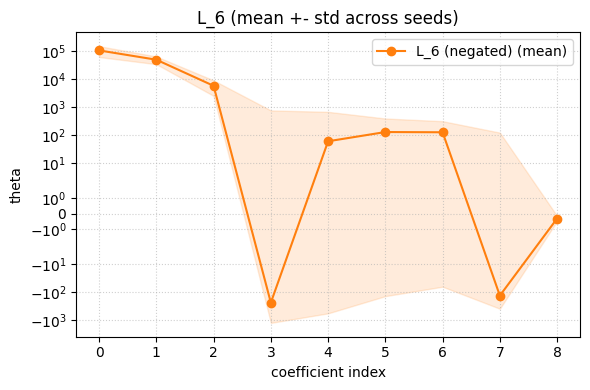

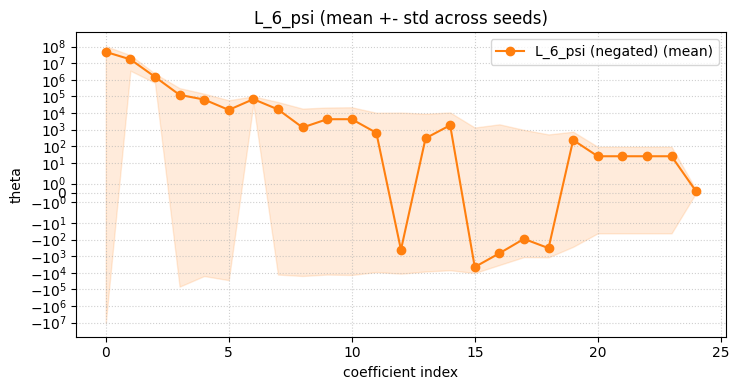

In [76]:
# ---------------------------------------------------------------------
# 12. Mean +- std across seeds for one linear (non-pruned) potential,
#     with verified column offsets instead of hardcoded slice indices.
# ---------------------------------------------------------------------
def plot_linear_potential_mean_std(theta_all, potentials, target_key, terms,
                                    label=None, sign=1, known_dims=None,
                                    color='tab:orange', yscale='symlog'):
    """
    Mean +- std across seeds for ONE potential's raw theta_t1 values,
    plotted against its own coefficient index -- for potentials like L_6 /
    L_6_psi that have a fixed (non-pruned) dimension every seed, so slicing
    theta_all by column offset is safe.
 
    theta_all: (n_seeds, n_features) tensor/array (e.g. mgd_all, reg_all).
    potentials: the FITTED potentials dict for a seed whose column layout
    matches theta_all -- use find_matching_reference_potentials to get one,
    same as everywhere else in this module. The offsets for `target_key`
    are read from theta_column_map (NOT hardcoded), so this is safe even if
    a preceding potential's width ever changes.
    sign: 1 or -1 -- multiplies the plotted line AND the shaded std band
    together, so they always represent the same quantity (unlike sign
    flips applied to only one of the two).
    yscale: 'symlog' (default) handles positive AND negative values
    correctly, unlike plain 'log' which silently drops non-positive points
    with no warning -- use 'linear' or 'symlog', not 'log', if theta can be
    negative (check with (theta_all[..., start:start+dim] < 0).any()).
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]
    col_map = theta_column_map(potentials, n_features, known_dims=known_dims, verbose=False)
    if target_key not in col_map:
        raise KeyError(f"'{target_key}' not in potentials: {list(potentials.keys())}")
    start, dim = col_map[target_key]
 
    theta_slice = sign * theta_np[:, start:start + dim]
    mean = theta_slice.mean(axis=0)
    std = theta_slice.std(axis=0)
 
    x = np.arange(dim)
    label = label or f"{target_key}{' (negated)' if sign == -1 else ''} (mean)"
    plt.figure(figsize=(max(6, dim * 0.3), 4))
    plt.plot(x, mean, marker='o', color=color, label=label)
    plt.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    if yscale != 'linear':
        plt.yscale(yscale)
    plt.title(f'{target_key} (mean +- std across seeds)')
    plt.xlabel('coefficient index')
    plt.ylabel('theta')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
 
    if (theta_slice < 0).any() and yscale == 'log':
        print(f"WARNING: {target_key} has negative values but yscale='log' -- "
              f"those points are invisible on the plot above. Use 'symlog' or 'linear'.")

ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)

plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6', terms, sign=-1)
plot_linear_potential_mean_std(reg_all, ref_potentials_reg, 'L_6_psi', terms, sign=-1)


In [35]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

## Theta signal to noise analysis 

In [36]:
# ------------------------------------------------------------
# Compute theta column ranges for each potential
# ------------------------------------------------------------
for name, X in {"Theta_reg": theta_reg, "Theta_MGD": theta_mgd}.items():
    mean = X.mean(axis=0)
    # ddof=1 per varianza/std campionaria corretta
    std = X.std(axis=0, ddof=1)
    var = std**2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean**2 + eps)
    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr
    )
# ------------------------------------------------------------
# 2. Correzione Loop Feature (Scatter plot anziché line plot)
# ------------------------------------------------------------
# Plot solo dei primi 4 parametri a titolo di esempio (evitiamo di bloccare il notebook)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    # Centriamo rispetto alla media delle seed
    mgd_centered = theta_mgd[:, i] - stats["Theta_MGD"]["mean"][i]
    reg_centered = theta_reg[:, i] - stats["Theta_reg"]["mean"][i]
    
    seeds_idx = np.arange(n_seeds)
    ax.scatter(seeds_idx, mgd_centered, label="MGD", color="tab:blue", alpha=0.7)
    ax.scatter(seeds_idx, reg_centered, label="REG", color="tab:orange", alpha=0.7)
    ax.axhline(0, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Feature Index {i} (Centered across seeds)")
    ax.set_xlabel("Seed Index")
    ax.set_ylabel("Deviazione dalla media")
    ax.legend()
plt.tight_layout()
plt.show()

reference_seed_name = f"seed{reference_key}"

reference_potentials = get_potentials_for_seed(
    reference_seed_name, M, base_args, root, device
)

sizes = {k: p.num_coefficients for k, p in reference_potentials.items()}

potential_ranges = {}
start = 0
for name, dim in sizes.items():
    potential_ranges[name] = (start, start + dim)
    start += dim

total_from_potentials = start
assert total_from_potentials == n_features_reg == n_features_mgd, (
    f"Potential-range total ({total_from_potentials}) doesn't match the actual "
    f"feature dimension from disk (theta_reg={n_features_reg}, theta_MGD={n_features_mgd}). "
    f"This means even the reference seed's pruning differs from the pooled theta arrays — "
    f"check that all seeds in `seeds_sorted` were fit with the same active regions."
)

print(potential_ranges)
potential_colors = {
    "L_6": "tab:blue",
    "L_6_psi": "tab:olive", 
    "L_2_lowpass": "tab:green",
    "Scattering_Fourth_Order_Mod2_Real_Q1": "tab:red",
    "Scattering_Fourth_Order_Mod2_Imag_Q1": "tab:purple",
    "Scalar_psi_gaussianK": "tab:orange",
    "Scalar_morlet_gaussianK": "tab:cyan", 
}

import os
import pandas as pd

# ------------------------------------------------------------
# Load saved file
# ------------------------------------------------------------
load_path = os.path.join(root, "saved_results", "final_theta_comparison.pt")
data = torch.load(load_path, map_location="cpu")

seeds = data["seeds"]

theta_reg = np.stack([
    data["theta_reg_final"][s].numpy()
    for s in seeds
])

theta_mgd = np.stack([
    data["theta_MGD_final"][s].numpy()
    for s in seeds
])

print("Theta_reg shape :", theta_reg.shape)
print("Theta_MGD shape :", theta_mgd.shape)

n_seeds, n_features = theta_reg.shape
%matplotlib inline
eps = 1e-12

stats = {}

for name, X in {
    "Theta_reg": theta_reg,
    "Theta_MGD": theta_mgd,
}.items():

    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    var = std**2

    cv = std / (np.abs(mean) + eps)

    rel_var = var / (mean**2 + eps)

    snr = np.abs(mean) / (std + eps)

    stats[name] = dict(
        mean=mean,
        std=std,
        var=var,
        cv=cv,
        rel_var=rel_var,
        snr=snr,
    )

summary = pd.DataFrame({
    "Theta_reg mean variance": [stats["Theta_reg"]["var"].mean()],
    "Theta_MGD mean variance": [stats["Theta_MGD"]["var"].mean()],

    "Theta_reg median variance": [np.median(stats["Theta_reg"]["var"])],
    "Theta_MGD median variance": [np.median(stats["Theta_MGD"]["var"])],

    "Theta_reg mean CV": [stats["Theta_reg"]["cv"].mean()],
    "Theta_MGD mean CV": [stats["Theta_MGD"]["cv"].mean()],

    "Theta_reg mean SNR": [stats["Theta_reg"]["snr"].mean()],
    "Theta_MGD mean SNR": [stats["Theta_MGD"]["snr"].mean()],
})

display(summary)
corrs = []

for j in range(n_features):
    c = np.corrcoef(theta_reg[:, j], theta_mgd[:, j])[0,1]
    corrs.append(c)

corrs = np.array(corrs)

print("Mean correlation :", np.nanmean(corrs))
print("Median correlation :", np.nanmedian(corrs))

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Variance across seeds")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.semilogy(stats["Theta_reg"]["rel_var"], label="Theta_reg")
plt.semilogy(stats["Theta_MGD"]["rel_var"], label="Theta_MGD")

plt.xlabel("Feature")
plt.ylabel("Relative variance")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))

plt.plot(stats["Theta_reg"]["snr"], label="Theta_reg")
plt.plot(stats["Theta_MGD"]["snr"], label="Theta_MGD")
plt.yscale("log") 
plt.xlabel("Feature")
plt.ylabel("Signal / Noise")
ymin, ymax = plt.ylim()

for name, (a, b) in potential_ranges.items():
    plt.axvspan(
        a, b,
        color=potential_colors[name],
        alpha=0.12,
        lw=0,
        label=name,
    )

plt.ylim(ymin, ymax)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))

plt.loglog(
    stats["Theta_reg"]["var"],
    stats["Theta_MGD"]["var"],
    "."
)

xmin = min(
    stats["Theta_reg"]["var"].min(),
    stats["Theta_MGD"]["var"].min()
)
xmax = max(
    stats["Theta_reg"]["var"].max(),
    stats["Theta_MGD"]["var"].max()
)

plt.plot([xmin,xmax],[xmin,xmax],"k--")

plt.xlabel("Variance Theta_reg")
plt.ylabel("Variance Theta_MGD")
plt.tight_layout()
plt.show()

idx = np.argsort(stats["Theta_reg"]["var"])[::-1]

print("Largest Theta_reg variances")
for i in idx[:10]:
    print(i, stats["Theta_reg"]["var"][i])

print()

idx = np.argsort(stats["Theta_MGD"]["var"])[::-1]

print("Largest Theta_MGD variances")
for i in idx[:10]:
    print(i, stats["Theta_MGD"]["var"][i])

NameError: name 'theta_mgd' is not defined

## Theta scaling analysis 

In [75]:
"""
theta_analysis_v2.py

Cleaned-up version of theta_analysis.py / theta_plotting.py, with four changes
relative to the original notebook code:

1. All the internal diagnostic prints (column maps, index-decoding fingerprint
   messages, etc.) are OFF by default. Every function still accepts
   verbose=True if you want to debug a specific case.

2. Legends are drawn on each subplot (ax.legend(...)) instead of a single
   fig.legend(...) floating above/outside the figure.

3. `Scattering_Fourth_Order_Mod2_Real_Q1` and `..._Imag_Q1` are no longer
   treated as two independent real potentials. `build_complex_theta_dataframe`
   pairs them coefficient-by-coefficient into theta_complex = real + i*imag,
   and the modulus used everywhere downstream (|theta|, variance, plots) is
   the modulus of that complex number, not of the real part alone.

4. `build_all_averaged_vectors` produces one readable dict {potential_name:
   averaged_theta_vector} per experiment type (MGD / Reg), averaged over
   seeds, with the Real/Imag Q1 pair collapsed into a single complex vector.
   These are plain 1D numpy arrays (real or complex) you can slice, plot, or
   feed into further analysis directly.

Assumptions worth flagging explicitly (adjust if wrong for your setup):
- Real/Imag potentials of the same family are assumed to be built with the
  same J, Q, offset, lite settings, so that every (j, s1, s2) coefficient the
  imaginary branch has is ALSO present in the real branch (just possibly not
  vice versa -- e.g. the real branch commonly keeps diagonal terms the
  imaginary branch prunes because they're identically zero). theta_complex is
  built on the real branch's layout; any real-branch coefficient absent from
  the imaginary branch gets an imaginary part of exactly 0.0. If the
  imaginary branch ever has a coefficient the real branch lacks,
  `expand_imag_to_real_indices` raises rather than silently dropping it.
- The moment-normalization for the complex case is
  theta_complex * (mk_real + i*mk_imag), i.e. the same elementwise
  fitted-times-moment convention as the real case, just extended to complex.
  This is a direct generalization, not something derived from first
  principles for the Mod2 potential -- double check it matches your intended
  physical normalization if you use `theta_complex_normalized` downstream.
"""

import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def expand_imag_to_real_indices(pot_im, pot_re, theta_im, verbose=False, index_convention='mod2'):
    """
    Re-express theta_im (defined on pot_im's own coefficient ordering) onto
    the coefficient layout of pot_re. Any index triplet that pot_re has but
    pot_im does not -- e.g. the diagonal terms, which are identically zero
    for an Im(z * conj(z))-type potential and so are typically pruned out
    of the imaginary branch entirely -- is filled with 0.0.

    Matching is done on the raw index triplet from `.indices` (3, n_coeff):
    one shared/singleton axis plus an unordered pair of the other two, so
    swapping the pair's order is treated as the same coefficient.

    index_convention: WHICH raw column is the singleton vs the pair matters
    -- getting it wrong doesn't just mislabel columns, it can silently
    CROSS-MATCH two physically different coefficients whose raw triples
    happen to collide under the wrong symmetry grouping (e.g. a genuine
    real 'diagonal' entry, which should get imaginary part exactly 0,
    picking up an unrelated surviving imaginary coefficient's value
    instead). Two conventions are supported:
        'mod2' (default) -- pair = (col[0], col[1]), singleton = col[2].
            Verified against Scattering_Fourth_Order_Mod2_{Real,Imag}_1d's
            actual forward()/fit_micro tensor shapes (col[0],col[1] are the
            fine, first-layer s1,s2; col[2] is the coarse, second-layer
            j2) -- this is what that potential family actually needs.
        'jab' -- pair = (col[1], col[2]), singleton = col[0]. This is
            decode_jab's assumed convention, for OTHER scattering
            potentials that might genuinely have that (different) index
            structure -- do NOT use this for the Mod2 potentials.

    Parameters
    ----------
    pot_im, pot_re : potentials with a `.indices` tensor of shape (3, dim)
    theta_im : array-like, shape (dim_im,) or (T, dim_im). theta_im.shape[-1]
        must equal pot_im.indices.shape[-1] -- pass pot_im's OWN theta slice,
        not something already sliced to dim_re.

    Returns
    -------
    theta_im_full : ndarray, shape (dim_re,) or (T, dim_re), dtype matching
        theta_im. Position i holds pot_im's value whenever pot_re's i-th
        index triplet also appears in pot_im, and 0.0 otherwise.
    """
    idx_re = pot_re.indices.long().detach().cpu().numpy()   # (3, dim_re)
    idx_im = pot_im.indices.long().detach().cpu().numpy()   # (3, dim_im)
    dim_re = idx_re.shape[-1]
    dim_im = idx_im.shape[-1]

    theta_im_arr = theta_im.detach().cpu().numpy() if torch.is_tensor(theta_im) else np.asarray(theta_im)
    if theta_im_arr.shape[-1] != dim_im:
        raise ValueError(
            f"theta_im last dim ({theta_im_arr.shape[-1]}) doesn't match "
            f"pot_im.indices ({dim_im}) -- pass pot_im's own theta slice, "
            f"not one already sliced/expanded to the real potential's size."
        )

    if index_convention == 'mod2':
        def _key(col):
            s1, s2, shared = int(col[0]), int(col[1]), int(col[2])
            lo, hi = (s1, s2) if s1 <= s2 else (s2, s1)
            return (shared, lo, hi)
    elif index_convention == 'jab':
        def _key(col):
            shared, s1, s2 = int(col[0]), int(col[1]), int(col[2])
            lo, hi = (s1, s2) if s1 <= s2 else (s2, s1)
            return (shared, lo, hi)
    else:
        raise ValueError(f"index_convention must be 'mod2' or 'jab', got '{index_convention}'")

    imag_map = {}
    for i in range(dim_im):
        key = _key(idx_im[:, i])
        if key in imag_map:
            raise ValueError(f"duplicate index {key} within the imaginary potential -- "
                              f"cannot build a unique coefficient mapping.")
        imag_map[key] = i

    is_2d = theta_im_arr.ndim == 2
    shape = (theta_im_arr.shape[0], dim_re) if is_2d else (dim_re,)
    theta_im_full = np.zeros(shape, dtype=theta_im_arr.dtype)

    n_matched = 0
    for i in range(dim_re):
        j = imag_map.get(_key(idx_re[:, i]))
        if j is not None:
            n_matched += 1
            theta_im_full[..., i] = theta_im_arr[..., j]
        # else: coefficient exists on the real branch but not the imaginary
        # one (e.g. diagonal) -- leave at 0.0.

    if verbose:
        print(f"expand_imag_to_real_indices: matched {n_matched}/{dim_re} real coefficients "
              f"({dim_re - n_matched} filled with 0.0); imaginary potential had {dim_im} coefficients.")
    if n_matched < dim_im:
        raise ValueError(
            f"{dim_im - n_matched} imaginary coefficients did not match any real-potential "
            f"index -- the imaginary branch has entries the real branch doesn't, so it can't "
            f"be losslessly expanded onto the real layout. Check J/Q/offset/lite settings match."
        )

    return theta_im_full


# ---------------------------------------------------------------------
# 1. Column mapping: potentials dict -> theta_t column slices
# ---------------------------------------------------------------------
def _potential_width(p, key, known_dims=None):
    """(dim, source) for potential p. Never silently assumes dim=1."""
    known_dims = known_dims or {}
    for attr in ('n_theta', 'num_theta', 'theta_dim'):
        if hasattr(p, attr):
            val = getattr(p, attr)
            val = val() if callable(val) else val
            if torch.is_tensor(val):
                val = val.numel()
            return int(val), f"'{attr}'"
    if hasattr(p, 'num_coefficients'):
        return int(p.num_coefficients), "'num_coefficients'"
    if hasattr(p, 'indices'):
        idx = p.indices
        width = idx.shape[-1] if torch.is_tensor(idx) else np.asarray(idx).shape[-1]
        return int(width), "'.indices.shape[-1]'"
    for attr in ('num_regions', 'n_regions'):
        if hasattr(p, attr):
            n_reg = int(getattr(p, attr))
            n_par = int(getattr(p, 'n_params_per_region', 1))
            return n_reg * n_par, f"'{attr}' x n_params_per_region"
    if key in known_dims:
        return int(known_dims[key]), "known_dims override (UNVERIFIED by introspection)"
    raise RuntimeError(f"Cannot determine theta width for '{key}' ({type(p).__name__}).")


def theta_column_map(potentials, n_theta, known_dims=None, verbose=False):
    """
    dict: key -> (start, dim) column slice into theta_t, for every potential
    in `potentials` (dict, insertion-order must equal theta_t column order,
    which is how get_1d_potentials + run_experiment build it).
    """
    keys = list(potentials.keys())
    dims, sources = [], []
    for k in keys:
        d, src = _potential_width(potentials[k], k, known_dims)
        dims.append(d)
        sources.append(src)
    offsets = np.cumsum([0] + dims)
    if sum(dims) != n_theta:
        lines = "\n".join(f"  {k:35s} {d:5d}  {s}" for k, d, s in zip(keys, dims, sources))
        raise AssertionError(
            f"sum(dims)={sum(dims)} != theta_t.shape[1]={n_theta}\n{lines}\n\n"
            f"Likely cause: `potentials` here is the freshly-constructed, NOMINAL "
            f"potentials dict (e.g. straight from get_1d_potentials(...)), whose "
            f"coefficient counts are the theoretical/un-pruned sizes. Per-seed "
            f"fitting can nondeterministically prune potentials (e.g. "
            f"Scalar_GGD_KRegion-based ones) down to fewer coefficients. Pass the "
            f"ACTUAL fitted potentials for a seed whose layout matches this theta "
            f"(e.g. via get_potentials_for_seed(...) / load_potentials_for_config(...)), "
            f"not the plain get_1d_potentials(...) output. See "
            f"find_matching_reference_potentials() for picking one automatically."
        )
    if verbose:
        for k, d, o, s in zip(keys, dims, offsets[:-1], sources):
            print(f"{k:35s} {d:5d}  [{o:4d}:{o+d:<4d}]  {s}")
    return {k: (int(o), int(d)) for k, o, d in zip(keys, offsets[:-1], dims)}


def find_matching_reference_potentials(theta_all, potentials_by_seed, known_dims=None):
    """
    `theta_all` (n_seeds, n_features) was built by stacking each seed's
    theta -- which only works if every kept seed happens to share the same
    pruned column layout. This picks out ONE such seed's actual FITTED
    potentials dict (not the nominal, un-pruned one) so you have something
    valid to pass to theta_column_map / build_all_averaged_vectors.

    potentials_by_seed: dict {seed_key: potentials_dict}, where each
    potentials_dict is the per-seed FITTED potentials, e.g. as returned by
    your own get_potentials_for_seed(...) / load_potentials_for_config(...)
    -- collect these into a dict as you loop over seeds building dfs/dfs_reg,
    the same way `potentials_by_seed[key] = potentials_k` was already being
    done in your seed-loading loop.

    Returns (seed_key, potentials_dict, col_map) for the first seed whose
    total coefficient count equals theta_all.shape[-1]. Raises with a
    per-seed breakdown if none match.
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]

    totals = {}
    for seed_key, potentials_k in potentials_by_seed.items():
        total = sum(_potential_width(p, k, known_dims)[0] for k, p in potentials_k.items())
        totals[seed_key] = total
        if total == n_features:
            col_map = theta_column_map(potentials_k, n_features, known_dims=known_dims, verbose=False)
            return seed_key, potentials_k, col_map

    raise ValueError(
        f"No seed's fitted potentials sum to theta_all's {n_features} columns.\n"
        f"Per-seed totals: {totals}"
    )


# ---------------------------------------------------------------------
# 2. Load theta for one target potential
# ---------------------------------------------------------------------
def load_theta_for_potential(theta_final, potentials, target_key, known_dims=None, verbose=False):
    """
    Slice theta_t down to the columns of `target_key`.
    Returns (theta_raw: np.ndarray (dim,) or (T, dim), potential, start, dim).
    """
    theta_1_np = theta_final.detach().cpu().numpy() if torch.is_tensor(theta_final) else np.asarray(theta_final)
    col_map = theta_column_map(potentials, len(theta_final), known_dims, verbose)
    # (was `potentials_k` in an earlier edit -- that name isn't in scope here
    # and would NameError; this function only ever sees `potentials`.)
    if target_key not in col_map:
        raise KeyError(f"'{target_key}' not in potentials: {list(potentials.keys())}")
    start, dim = col_map[target_key]

    potential = potentials[target_key]
    if hasattr(potential, 'num_coefficients') and hasattr(potential, 'indices'):
        assert dim == potential.num_coefficients == potential.indices.shape[-1], (
            f"dim mismatch: col_map={dim}, num_coefficients={potential.num_coefficients}, "
            f"indices={potential.indices.shape[-1]}"
        )

    theta_raw = theta_1_np[start:start + dim]
    if verbose:
        print(f"-> {target_key}: cols [{start}:{start + dim}] out of {theta_1_np.shape[-1]}")
    return theta_raw, potential, start, dim


# ---------------------------------------------------------------------
# 3. Decode (j, a, b) indices for a 4th-order potential
# ---------------------------------------------------------------------
def decode_jab(potential, j_row=None, verbose=False):
    """
    potential.indices is (3, n_coeff): one row is the shared first-layer
    scale j, the other two are absolute second-layer scales s1,s2. Detect
    which row is j via the combinatorial fingerprint for offset=1, lite=True,
    no-diag: #pairs at fixed j == C(J-j, 2). Pass j_row explicitly to skip
    detection / override a bad guess.
    Returns j, a, b, s1, s2 (np.ndarray, a=min(s)-j < b=max(s)-j), j_row.
    """
    idx = potential.indices.long().detach().cpu()
    J = potential.J

    if j_row is None:
        expected = {j: math.comb(J - j, 2) for j in range(J)}
        expected = {j: c for j, c in expected.items() if c > 0}
        row_vc = []
        for r in range(3):
            vals = idx[r].numpy()
            uniq, counts = np.unique(vals, return_counts=True)
            row_vc.append(dict(zip(uniq.tolist(), counts.tolist())))
        j_row = next((r for r in range(3) if row_vc[r] == expected), None)
        if j_row is None:
            def mismatch(vc):
                ks = set(vc) | set(expected)
                return sum(abs(vc.get(k, 0) - expected.get(k, 0)) for k in ks)
            scores = [mismatch(vc) for vc in row_vc]
            j_row = int(np.argmin(scores))
            if verbose:
                print(f"WARNING: no exact fingerprint match, best guess j_row={j_row} "
                      f"(mismatch scores {scores}); pass j_row= explicitly if this is wrong.")
        elif verbose:
            print(f"-> detected j_row={j_row} from combinatorial fingerprint.")

    other = [r for r in range(3) if r != j_row]
    j = idx[j_row].numpy()
    s1_raw, s2_raw = idx[other[0]].numpy(), idx[other[1]].numpy()
    lo, hi = np.minimum(s1_raw, s2_raw), np.maximum(s1_raw, s2_raw)
    a, b = lo - j, hi - j

    if verbose and not ((a >= 1).all() and (b > a).all()):
        print(f"WARNING: offset/lite assumptions violated: {(a < 1).sum()} entries a<1, "
              f"{(b <= a).sum()} entries b<=a. j_row={j_row} may be wrong -- check manually.")
    return j, a, b, lo, hi, j_row


def decode_mod2_stq(potential, verbose=False):
    """
    Decode the ACTUAL index structure of
    Scattering_Fourth_Order_Mod2_{Real,Imag}_1d potentials -- verified by
    tracing the tensor shapes through forward(): the outer-product tensor
    just before indexing has shape (B, J*Q, J*Q, J+1), NOT (B, J+1, J+1,
    J*Q) as that class's own inline comments claim. So
    output[:, indices[0], indices[1], indices[2]] means:

        indices[0], indices[1] -- a PAIRED, symmetric pair of FINE,
            first-layer scale indices s1, s2, each in [0, J*Q) -- which two
            (Q-oversampled, sub-octave) first-layer channels' envelope
            fluctuations are being correlated. fit_micro's own
            norm_indices = self.norm[:,None]*self.norm[None,:] (an outer
            product over a length-J*Q vector, then merely broadcast --
            not varied -- across J+1) independently confirms this.
        indices[2] -- the SHARED, single COARSE second-layer scale j2, in
            [0, J] (J+1 values, including low-pass) -- the resolution at
            which that correlation is evaluated.

    This is a DIFFERENT axis structure from decode_jab, which assumes the
    shared axis is a small-range "first-layer j" and the paired axes are
    two "second-layer scales s1,s2 > j" living in the SAME space as j.
    Applying decode_jab here mislabels the axes: j2 and s1/s2 live in
    non-comparable spaces (J+1 vs J*Q), so decode_jab's a=s-j, b=s-j
    subtracts a coarse index from a fine one -- not a real scale
    separation. That's the likely cause of |theta| appearing to GROW with
    "k" instead of decay: k wasn't measuring scale separation at all.

    Returns (j2, s1, s2): j2 shape (n_coeff,) in [0, J]; s1, s2 shape
    (n_coeff,), sorted (s1 <= s2), both in [0, J*Q).
    """
    idx = potential.indices.long().detach().cpu().numpy()
    if idx.shape[0] != 3:
        raise ValueError(f"expected potential.indices with 3 rows, got {idx.shape[0]}.")
    s1_raw, s2_raw, j2 = idx[0], idx[1], idx[2]
    s1, s2 = np.minimum(s1_raw, s2_raw), np.maximum(s1_raw, s2_raw)
    if verbose:
        JQ = potential.J * potential.Q
        print(f"decode_mod2_stq: s1,s2 in [0,{JQ}) (fine, first-layer, J*Q={JQ} channels), "
              f"j2 in [0,{potential.J}] (coarse, second-layer, J+1 channels incl. low-pass).")
    return j2, s1, s2


# ---------------------------------------------------------------------
# 3b. Region-pruned scalar potentials (Scalar_GGD_KRegion-style): decode
#     per-coefficient channel index, since these do NOT have a fixed
#     J*Q+1 layout -- num_coefficients = sum over J channels of however
#     many of the K candidate regions survived fitting-time pruning.
# ---------------------------------------------------------------------
def inspect_fitted_scalar_potential(p):
    """
    Print the attributes that plausibly encode per-coefficient channel
    assignment for a region-based scalar potential (K max regions per
    channel, J channels, num_coefficients = sum of active regions across
    channels after fitting-time pruning).

    IMPORTANT: run this on an ACTUALLY FITTED potential (e.g. one seed's
    entry from get_potentials_for_seed(...) / potentials_by_seed), not the
    nominal unfitted one -- Keff/active/active_flat/scale/alpha are only
    populated after fitting, and decode_scalar_channel needs to see real
    values to pick the right decoding path.
    """
    for name in ("K", "J", "num_coefficients", "Keff", "active", "active_flat",
                 "scale", "alpha", "cuts", "pi", "sw", "stat_scale"):
        val = getattr(p, name, "<missing attribute>")
        if val is None or isinstance(val, (int, float, str)):
            print(f"{name:16s} {val}")
        elif torch.is_tensor(val):
            print(f"{name:16s} tensor shape={tuple(val.shape)} dtype={val.dtype}")
        elif isinstance(val, np.ndarray):
            print(f"{name:16s} ndarray shape={val.shape} dtype={val.dtype}")
        else:
            print(f"{name:16s} {type(val).__name__} {val}")


def decode_scalar_channel(potential, verbose=False):
    """
    Per-coefficient channel index for a region-pruned scalar potential.
    Tries, in order:

    1. `active_flat`: an int array of FLAT INDICES into the (J, K) channel
       x region grid -- confirmed against a real fitted potential to have
       length == num_coefficients directly (NOT a boolean mask over the
       full J*K grid, which was this function's first, wrong guess).
       channel = active_flat[i] // K, region = active_flat[i] % K.
    2. `Keff`: per-channel active-region count, length J. Coefficients
       assumed ordered channel-major: Keff[0] coefficients for channel 0,
       then Keff[1] for channel 1, etc. (fallback only -- prefer
       active_flat, which doesn't depend on this ordering assumption at
       all since it gives the channel directly per coefficient).

    NOTE: potential.J here is NOT the number of wavelet octaves -- for a
    real fitted potential it was seen to be J_octaves*Q + 1 (e.g. 9 for a
    Q=1 'morlet' potential, 25 for a Q=3 'psi' potential with J_octaves=8),
    i.e. the same (octave, sub-band, low-pass) channel grid as the
    fixed-layout linear potentials (L_6/L_6_psi), just with per-channel
    region pruning on top.

    Returns channel_indices: int array, shape (num_coefficients,), values
    in [0, potential.J - 1].
    """
    K = getattr(potential, "K", None)
    J = getattr(potential, "J", None)
    n = getattr(potential, "num_coefficients", None)
    if K is None or J is None or n is None:
        raise RuntimeError("potential is missing K / J / num_coefficients -- can't decode channels.")

    active_flat = getattr(potential, "active_flat", None)
    if active_flat is not None:
        af = active_flat.detach().cpu().numpy() if torch.is_tensor(active_flat) else np.asarray(active_flat)
        af = af.reshape(-1)
        if af.shape[0] != n:
            raise ValueError(
                f"active_flat length {af.shape[0]} != num_coefficients={n} -- "
                f"unexpected shape for a flat-index array, inspect the potential directly."
            )
        channel_indices = (af // K).astype(int)
        if channel_indices.size and (channel_indices.max() >= J or channel_indices.min() < 0):
            raise ValueError(
                f"decoded channel indices out of range [0,{J}) -- active_flat may not "
                f"encode flat (channel,region) positions as assumed here."
            )
        if verbose:
            print(f"decode_scalar_channel: used active_flat (flat channel*K+region indices), "
                  f"{n} coefficients across {J} channels.")
        return channel_indices

    Keff = getattr(potential, "Keff", None)
    if Keff is not None:
        keff = Keff.detach().cpu().numpy() if torch.is_tensor(Keff) else np.asarray(Keff)
        if keff.shape[0] != J:
            raise ValueError(f"Keff length {keff.shape[0]} != J={J}.")
        if int(keff.sum()) != n:
            raise ValueError(
                f"sum(Keff)={int(keff.sum())} != num_coefficients={n} "
                f"-- channel-major ordering assumption doesn't hold; inspect the potential directly."
            )
        channel_indices = np.repeat(np.arange(J), keff.astype(int))
        if verbose:
            print(f"decode_scalar_channel: used Keff, {n} coefficients across {J} channels.")
        return channel_indices.astype(int)

    raise RuntimeError(
        "Neither active_flat nor Keff is populated on this potential -- make sure "
        "you're passing a FITTED potential (e.g. one entry from potentials_by_seed), "
        "not the nominal unfitted one. If both ARE populated and this still fails, "
        "run inspect_fitted_scalar_potential(p), share what you see, and adjust the "
        "channel-major ordering assumption above."
    )


# ---------------------------------------------------------------------
# 4. Moment features (for the "physical" normalization theta * m_k)
# ---------------------------------------------------------------------
def compute_mk(potentials, x1):
    mk = []
    with torch.no_grad():
        for p in potentials.values():
            feat = p(x1)
            if feat.ndim == 1:
                feat = feat[:, None]
            mk.append(feat.mean(0))
    return torch.cat(mk).cpu().numpy()


def compute_stdk(potentials, x1, unbiased=True):
    """
    Per-coefficient Std[phi_k(x)] across x1's batch dimension, concatenated
    across potentials in the SAME column order as compute_mk (mirrors it
    exactly, .std() instead of .mean()). Use this together with
    build_all_averaged_vectors -- the same way mk_all/mk_vectors were built
    -- to get std_vectors for
    build_octave_energy_comparison(..., energy_kind='std').

    unbiased: passed to torch.std (ddof=1 sample std if True), matching the
    ddof=1 convention already used elsewhere in this codebase (the
    cross-seed variance/CV/SNR diagnostics). Gives NaN for any potential
    whose feature has a batch dimension of 1 -- same caveat as ddof=1
    anywhere else.
    """
    sk = []
    with torch.no_grad():
        for p in potentials.values():
            feat = p(x1)
            if feat.ndim == 1:
                feat = feat[:, None]
            sk.append(feat.std(0, unbiased=unbiased))
    return torch.cat(sk).cpu().numpy()


# ---------------------------------------------------------------------
# 5a. Tidy dataframe for one REAL-valued potential
# ---------------------------------------------------------------------
def compute_norm_jab(x1, filters, s1_arr, s2_arr, order=2):
    """
    norm_jab[i] = (E[|Wx_s1|^2] * E[|Wx_s2|^2]) ** (order/4), Wx_s = single-
    layer wavelet transform of x1 at absolute scale s, using the same J+1-
    channel `filters` bank the potential's second layer uses.
    order=2 -> sqrt(E1*E2)  (plain Real/Imag potentials, micro-norm on |x|)
    order=4 -> E1*E2        (Mod2 potentials, micro-norm on |x|^2 -- this is
               the one for Scattering_Fourth_Order_Mod2_Real_Q1 /
               ..._Mod2_Imag_Q1, which is what this codebase actually uses)
    Runs on x1's device; filters moved to match, no_grad, no side effects.
    """
    filters = filters.to(x1.device)
    with torch.no_grad():
        Wx_full = torch.fft.ifft(filters * torch.fft.fft(x1))                    # (B, J+1, T)
        E_scale = (Wx_full.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()   # (J+1,)
    s1_arr, s2_arr = np.asarray(s1_arr), np.asarray(s2_arr)
    return (E_scale[s1_arr] * E_scale[s2_arr]) ** (order / 4)


def build_theta_dataframe(theta_final, potentials, target_key, x1, filters,
                           m_k=None, norm_order=None, known_dims=None, verbose=False):
    """
    Builds a tidy dataframe for a single, real-valued target_key. Decodes
    (j, a, b) indices if the potential has scattering index structure,
    otherwise builds a generic coefficient table.

    Normalization (theta_t1_normalized):
    - Potentials WITH scattering index structure (.indices): the physical
      micro-norm convention theta_physical = theta_fitted *
      (E[|Wx_s1|^2]*E[|Wx_s2|^2])**(norm_order/4), via compute_norm_jab,
      evaluated at each coefficient's own (s1, s2) scales.
        If 'Mod2' is in target_key (Scattering_Fourth_Order_Mod2_Real/Imag):
        uses decode_mod2_stq for indexing -- s1, s2 are FINE, first-layer
        scale indices in [0, J*Q), and j2 (the shared axis) is the COARSE,
        second-layer scale in [0, J] -- and evaluates compute_norm_jab
        against potential.filters_Q (the fine bank), NOT potential.filters,
        since that's the bank fit_micro actually used to build self.norm
        for this potential class (verified against its source: self.norm
        has shape (J*Q,), an outer product over that axis, merely
        broadcast -- not varied -- across the J+1 axis). Using
        potential.filters here instead would silently compute the wrong
        micro-norm.
        Otherwise: uses decode_jab (shared axis = "first-layer" j in
        [0,J), paired axes = "second-layer" s1,s2 > j, same space as j)
        and potential.filters, falling back to the `filters` argument only
        if the potential doesn't carry its own.
        norm_order=2 -> sqrt(E1*E2)  for plain Real/Imag potentials
        norm_order=4 -> E1*E2        for Mod2_Real/Mod2_Imag potentials
      If norm_order is left as None, it's inferred the same way: 4 if
      'Mod2' is in target_key, else 2 -- pass it explicitly if that
      heuristic is wrong for a given potential's naming.
    - Potentials WITHOUT .indices (L_6, L_2_lowpass, Scalar_*): there's no
      per-coefficient (s1, s2) to feed compute_norm_jab, so this falls back
      to the old theta_fitted * m_k convention if `m_k` is supplied, or NaN
      if it isn't.
    """
    theta_raw, potential, start, dim = load_theta_for_potential(
        theta_final, potentials, target_key, known_dims, verbose
    )
    final_theta = theta_raw[-1] if theta_raw.ndim == 2 else theta_raw

    if hasattr(potential, 'indices'):
        is_mod2 = 'Mod2' in target_key
        if is_mod2:
            j_arr, s1_arr, s2_arr = decode_mod2_stq(potential, verbose=verbose)
            pot_filters = getattr(potential, 'filters_Q', filters)
        else:
            j_arr, a_arr, b_arr, s1_arr, s2_arr, j_row = decode_jab(potential, verbose=verbose)
            pot_filters = getattr(potential, 'filters', filters)

        order = norm_order if norm_order is not None else (4 if is_mod2 else 2)
        norm = compute_norm_jab(x1, pot_filters, s1_arr, s2_arr, order=order)
        final_theta_normalized = final_theta * norm

        df = pd.DataFrame({
            'potential': target_key,
            'coeff_idx': np.arange(dim),
            'j': j_arr, 'k_prime': s1_arr, 'k': s2_arr,
            'theta_t1': final_theta,
            'theta_t1_normalized': final_theta_normalized,
        })
    else:
        if m_k is not None:
            mk_slice = m_k[start:start + dim]
            norm_mk = final_theta * mk_slice
            final_theta_normalized = np.where(norm_mk != 0, norm_mk, np.nan)
        else:
            final_theta_normalized = np.full(dim, np.nan)
        df = pd.DataFrame({
            'potential': target_key,
            'coeff_idx': np.arange(dim),
            'theta_t1': final_theta,
            'theta_t1_normalized': final_theta_normalized,
        })
    return df


# ---------------------------------------------------------------------
# 5b. Tidy dataframe for a REAL+i*IMAG pair, combined as a complex vector
# ---------------------------------------------------------------------
def build_complex_theta_dataframe(theta_final, potentials, real_key, imag_key, x1, filters,
                                   combined_name=None, m_k=None, norm_order=None,
                                   known_dims=None, verbose=False):
    """
    Pairs `real_key` and `imag_key` coefficient-by-coefficient into
    theta_complex = theta_real + i*theta_imag, and returns a tidy dataframe
    with the shared (j, k', k) index structure (taken from the real
    potential).

    Normalization (theta_complex_normalized):
    - If the real potential has scattering index structure (.indices): the
      SAME physical micro-norm convention as build_theta_dataframe --
      theta_physical = theta_complex * (E[|Wx_s1|^2]*E[|Wx_s2|^2])**(norm_order/4),
      via compute_norm_jab, evaluated ONCE at the REAL potential's own
      (s1, s2) scales. If 'Mod2' is in real_key, uses decode_mod2_stq (s1,s2
      are FINE, first-layer indices in [0,J*Q); j (the shared axis) is the
      COARSE, second-layer scale in [0,J]) and pot_re.filters_Q (the fine
      bank -- verified against that class's fit_micro, which builds its own
      micro-norm from filters_Q, not filters). Otherwise uses decode_jab and
      pot_re.filters, falling back to the `filters` argument only if the
      potential doesn't have its own. Because theta_im was already expanded
      onto pot_re's index layout below (using the matching index_convention),
      each complex coefficient's (s1, s2) is shared between its real and
      imaginary parts, so this one real-valued norm array multiplies
      directly into the complex vector -- no separate real/imag norm needed.
        norm_order=2 -> sqrt(E1*E2)  for plain Real/Imag potential pairs
        norm_order=4 -> E1*E2        for Mod2_Real/Mod2_Imag pairs -- this
                         is the one for Scattering_Fourth_Order_Mod2_Real_Q1
                         / ..._Mod2_Imag_Q1, which is what this codebase
                         actually uses.
      If norm_order is left as None, it's inferred from the name: 4 if
      'Mod2' is in real_key, else 2 -- pass it explicitly if that heuristic
      is wrong for a given pair's naming.
    - If the real potential has no .indices: there's no (s1, s2) to feed
      compute_norm_jab, so this falls back to the old
      theta_complex * (mk_re + i*mk_im) convention if `m_k` is supplied
      (mk_re/mk_im sliced the same way theta_re/theta_im were -- valid here
      because reaching this branch already guarantees dim_re == dim_im, see
      below), or leaves theta_complex_normalized as NaN+NaNj if `m_k` isn't
      given either.

    All downstream aggregation (aggregate_theta_across_seeds) takes
    |theta_complex|, i.e. the modulus over BOTH components jointly, not the
    real part alone.
    """
    combined_name = combined_name or real_key.replace('_Real', '').replace('Real_', '')
    is_mod2 = 'Mod2' in real_key

    theta_re, pot_re, start_re, dim_re = load_theta_for_potential(
        theta_final, potentials, real_key, known_dims, verbose)
    theta_im, pot_im, start_im, dim_im = load_theta_for_potential(
        theta_final, potentials, imag_key, known_dims, verbose)

    # The imaginary branch typically has FEWER coefficients than the real one
    # (e.g. diagonal terms are identically zero for Im(z*conj(z)) and get
    # pruned out), so we can't assume matching shapes or identical `.indices`.
    # Expand theta_im onto pot_re's own index layout, zero-filling wherever
    # pot_re has a coefficient pot_im doesn't.
    if hasattr(pot_re, 'indices') and hasattr(pot_im, 'indices'):
        theta_im_expanded = expand_imag_to_real_indices(
            pot_im, pot_re, theta_im, verbose=verbose,
            index_convention='mod2' if is_mod2 else 'jab',
        )
    elif dim_re == dim_im:
        theta_im_expanded = theta_im
    else:
        raise ValueError(
            f"'{real_key}' and '{imag_key}' have no index structure to align on "
            f"(missing .indices) and different sizes ({dim_re} vs {dim_im}) -- "
            f"cannot pair them coefficient-wise."
        )

    theta_re_final = theta_re[-1] if theta_re.ndim == 2 else theta_re
    theta_im_final = theta_im_expanded[-1] if theta_im_expanded.ndim == 2 else theta_im_expanded
    theta_complex = theta_re_final + 1j * theta_im_final

    if hasattr(pot_re, 'indices'):
        if is_mod2:
            j_arr, s1_arr, s2_arr = decode_mod2_stq(pot_re, verbose=verbose)
            pot_filters = getattr(pot_re, 'filters_Q', filters)
        else:
            j_arr, a_arr, b_arr, s1_arr, s2_arr, j_row = decode_jab(pot_re, verbose=verbose)
            pot_filters = getattr(pot_re, 'filters', filters)

        order = norm_order if norm_order is not None else (4 if is_mod2 else 2)
        norm = compute_norm_jab(x1, pot_filters, s1_arr, s2_arr, order=order)
        theta_complex_normalized = theta_complex * norm

        df = pd.DataFrame({
            'potential': combined_name,
            'coeff_idx': np.arange(dim_re),
            'j': j_arr, 'k_prime': s1_arr, 'k': s2_arr,
            'theta_complex': theta_complex,
            'theta_complex_normalized': theta_complex_normalized,
        })
    else:
        if m_k is not None:
            # dim_re == dim_im is guaranteed here -- the only way to reach
            # this branch (pot_re has no .indices) without raising above.
            mk_re = m_k[start_re:start_re + dim_re]
            mk_im = m_k[start_im:start_im + dim_im]
            theta_complex_normalized = theta_complex * (mk_re + 1j * mk_im)
        else:
            theta_complex_normalized = np.full(dim_re, np.nan + 1j * np.nan)
        df = pd.DataFrame({
            'potential': combined_name,
            'coeff_idx': np.arange(dim_re),
            'theta_complex': theta_complex,
            'theta_complex_normalized': theta_complex_normalized,
        })
    return df


# ---------------------------------------------------------------------
# 6. Cross-seed aggregation (works for real- or complex-valued columns:
#    np.abs() on a complex array returns the modulus)
# ---------------------------------------------------------------------
def aggregate_theta_across_seeds(dfs, value_col='theta_t1', group_cols=('j', 'k_prime', 'k')):
    """
    dfs: dict {seed_key: df}. Returns tidy df with group_cols +
    ['abs_mean', 'abs_std', 'n_seeds'], where abs_mean/abs_std are computed
    on |value_col| pooled across seeds (and across any index not in
    group_cols). If value_col holds complex numbers, |.| is the modulus.
    """
    group_cols = list(group_cols)
    frames = []
    for seed, df in dfs.items():
        missing = [c for c in group_cols + [value_col] if c not in df.columns]
        if missing:
            raise KeyError(f"seed '{seed}': dataframe missing columns {missing}")
        tmp = df[group_cols + [value_col]].copy()
        tmp['abs_val'] = np.abs(tmp[value_col])
        tmp['seed'] = seed
        frames.append(tmp)
    long = pd.concat(frames, ignore_index=True)

    agg = long.groupby(group_cols)['abs_val'].agg(['mean', 'std', 'count']).reset_index()
    agg = agg.rename(columns={'mean': 'abs_mean', 'std': 'abs_std', 'count': 'n_seeds'})
    agg['abs_std'] = agg['abs_std'].fillna(0.0)
    return agg


def build_agg_cases(cases):
    """cases: dict label -> {'dfs': {seed: df}, 'value_col': str, 'group_cols': tuple (optional)}"""
    out = {}
    for label, spec in cases.items():
        group_cols = spec.get('group_cols', ('j', 'k_prime', 'k'))
        out[label] = aggregate_theta_across_seeds(spec['dfs'], spec['value_col'], group_cols)
    return out


# ---------------------------------------------------------------------
# 7. Plotting -- legends live on each subplot now
# ---------------------------------------------------------------------
def _kprime_colors(k_primes):
    cmap = plt.get_cmap('viridis')
    n = len(k_primes)
    return {kp: cmap(idx / max(1, n - 1) * 0.85) for idx, kp in enumerate(sorted(k_primes))}


def _band_or_line(ax, x, mean, std, n_seeds, color, label, log_y=True):
    ax.plot(x, mean, 'o-', color=color, label=label, ms=4)
    if np.any(np.asarray(n_seeds) > 1):
        if log_y:
            lower = np.clip(mean - std, a_min=mean * 1e-3, a_max=None)
        else:
            lower = mean - std
        upper = mean + std
        ax.fill_between(x, lower, upper, color=color, alpha=0.2, linewidth=0)


def plot_modulus_vs_k_grid(agg_cases, log_y=True, panel_size=(3.2, 3.0)):
    """
    Rows = cases (e.g. MGD / Reg), columns = j. One line per k' per panel,
    legend drawn inside each panel.
    """
    labels = list(agg_cases.keys())
    all_js = sorted(set().union(*[set(df['j'].unique()) for df in agg_cases.values()]))
    all_kprimes = sorted(set().union(*[set(df['k_prime'].unique()) for df in agg_cases.values()]))
    colors = _kprime_colors(all_kprimes)

    n_rows, n_cols = len(labels), len(all_js)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(panel_size[0] * n_cols, panel_size[1] * n_rows),
                              sharex=True, sharey='row', squeeze=False)

    for row, label in enumerate(labels):
        df = agg_cases[label]
        for col, j in enumerate(all_js):
            ax = axes[row, col]
            sub = df[df['j'] == j]
            for kp in all_kprimes:
                g = sub[sub['k_prime'] == kp].sort_values('k')
                if g.empty:
                    continue
                _band_or_line(ax, g['k'].values, g['abs_mean'].values, g['abs_std'].values,
                               g['n_seeds'].values, colors[kp], rf"$k'={kp}$", log_y)
            if log_y:
                ax.set_yscale('log')
            if row == 0:
                ax.set_title(f'j={j}')
            if row == n_rows - 1:
                ax.set_xlabel('k')
            ax.legend(fontsize=7, loc='best')
        axes[row, 0].set_ylabel(f'{label}\n' + r'$|\theta_{j,k^{\prime},k}|$')

    fig.suptitle(r'$|\theta_{j,k^{\prime},k}|$ vs $k$, per $j$')
    plt.tight_layout()
    plt.show()


def plot_modulus_vs_j_grid(agg_cases, log_y=True, panel_size=(3.2, 3.0)):
    """
    Rows = cases, columns = k. One line per k' per panel, x-axis is j.
    Legend drawn inside each panel.
    """
    labels = list(agg_cases.keys())
    all_ks = sorted(set().union(*[set(df['k'].unique()) for df in agg_cases.values()]))
    all_kprimes = sorted(set().union(*[set(df['k_prime'].unique()) for df in agg_cases.values()]))
    colors = _kprime_colors(all_kprimes)

    n_rows, n_cols = len(labels), len(all_ks)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(panel_size[0] * n_cols, panel_size[1] * n_rows),
                              sharex=True, sharey='row', squeeze=False)

    for row, label in enumerate(labels):
        df = agg_cases[label]
        for col, k in enumerate(all_ks):
            ax = axes[row, col]
            sub = df[df['k'] == k]
            for kp in all_kprimes:
                g = sub[sub['k_prime'] == kp].sort_values('j')
                if g.empty:
                    continue
                _band_or_line(ax, g['j'].values, g['abs_mean'].values, g['abs_std'].values,
                               g['n_seeds'].values, colors[kp], rf"$k'={kp}$", log_y)
            if log_y:
                ax.set_yscale('log')
            if row == 0:
                ax.set_title(f'k={k}')
            if row == n_rows - 1:
                ax.set_xlabel('scale j')
            ax.legend(fontsize=7, loc='best')
        axes[row, 0].set_ylabel(f'{label}\n' + r'$|\theta_{j,k^{\prime},k}|$')

    fig.suptitle(r'$|\theta_{j,k^{\prime},k}|$ vs $j$, per $k$')
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 8. Readable, averaged-over-seeds theta vectors per potential
# ---------------------------------------------------------------------
def build_all_averaged_vectors(theta_all, potentials, terms, real_imag_pairs=(), known_dims=None):
    """
    theta_all: (n_seeds, n_features) tensor/array of final-time theta,
    stacked across seeds (e.g. `mgd_all` or `reg_all`).
    potentials: the FITTED potentials dict for ONE seed whose column layout
    actually matches theta_all's n_features -- e.g. from
    get_potentials_for_seed(...) / load_potentials_for_config(...), or
    auto-selected via find_matching_reference_potentials(theta_all,
    potentials_by_seed). Do NOT pass the freshly-constructed nominal
    potentials dict straight from get_1d_potentials(...): per-seed fitting
    can prune coefficients (e.g. Scalar_GGD_KRegion-based potentials), so its
    coefficient counts won't generally match theta_all's actual columns.
    terms: full list of potential names, in the same order used to build
    `potentials` (defines the column layout of theta_all).
    real_imag_pairs: list of (real_name, imag_name, combined_name) -- for
    each, the two averaged real vectors are combined into one complex
    vector combined_name = mean(real) + i*mean(imag), and the two raw
    entries are dropped from the returned dict.

    Returns dict: potential_name -> 1D np.ndarray (real or complex),
    averaged over seeds, ready to slice/plot/manipulate directly. E.g.:
        vectors['L_6'], vectors['L_6_psi'], vectors['Scalar_psi_gaussianK'],
        vectors['Scattering_Fourth_Order_Mod2_Q1']  (complex)
    """
    theta_np = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
    n_features = theta_np.shape[-1]
    col_map = theta_column_map(potentials, n_features, known_dims=known_dims, verbose=False)
    mean_theta = theta_np.mean(axis=0)

    vectors = {}
    for name in terms:
        if name not in col_map:
            continue
        start, dim = col_map[name]
        vectors[name] = mean_theta[start:start + dim]

    for real_name, imag_name, combined_name in real_imag_pairs:
        if real_name not in vectors or imag_name not in vectors:
            continue
        pot_re, pot_im = potentials[real_name], potentials[imag_name]
        if hasattr(pot_re, 'indices') and hasattr(pot_im, 'indices'):
            # imag branch is typically shorter (pruned diagonal etc.) --
            # expand it onto the real branch's layout, zero-filling gaps.
            imag_expanded = expand_imag_to_real_indices(
                pot_im, pot_re, vectors[imag_name],
                index_convention='mod2' if 'Mod2' in real_name else 'jab',
            )
        elif vectors[real_name].shape == vectors[imag_name].shape:
            imag_expanded = vectors[imag_name]
        else:
            raise ValueError(f"'{real_name}'/'{imag_name}' shape mismatch and no .indices "
                              f"to align on -- cannot combine.")
        vectors[combined_name] = vectors[real_name] + 1j * imag_expanded
        del vectors[real_name]
        del vectors[imag_name]

    return vectors


# ---------------------------------------------------------------------
# 9. m_k companion vectors + octave-level interacting vs non-interacting
#    energy comparison
#
#    "Non-interacting" = every potential except the 4th-order scattering
#    one: L_6, L_6_psi, L_2_lowpass, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK. "Interacting" = the 4th-order scattering
#    (Real + i*Imag, Mod2, Q1) potential.
#
#    The "psi"-family potentials are built with Q=3 (3 sub-bands per
#    octave), the "morlet"-family ones with Q=1, so their raw vectors have
#    different lengths (J*3+1 vs J*1+1). aggregate_octaves_from_QJ collapses
#    away the Q sub-band axis so every potential ends up as a J-length
#    octave profile (+ a separate scalar low-pass), directly comparable.
#    The scattering potential doesn't have this simple per-scale layout
#    (its coefficients are (j, k', k) triplets), so aggregate_by_j groups
#    its coefficients by shared j instead.
# ---------------------------------------------------------------------
def aggregate_octaves_from_QJ(vec, J, Q, agg='sum'):
    """
    Collapse a length J*Q+1 coefficient vector -- Q sub-band coefficients
    per octave j=0..J-1 (ordered j-major, index = j*Q + q), followed by one
    trailing low-pass coefficient -- down to a length-J octave profile by
    combining away the Q sub-band axis, plus the low-pass value on its own.

    This is what lets a Q=3 ('psi') potential and a Q=1 ('morlet') potential
    be compared octave-for-octave: after this, both are length J (+ one
    scalar low-pass), regardless of their original Q.

    agg: 'sum' (default) or 'mean'. Use 'sum' when `vec` already holds a
    per-coefficient ENERGY (theta_k * m_k) you want a total for -- sum is
    invariant to how many sub-band coefficients happen to exist, which
    matters once some are pruned away (see aggregate_by_j). Use 'mean' only
    if you specifically want an average coefficient magnitude, not a total.

    ASSUMPTION (flag if it doesn't match your indexing): the vector is
    ordered j-major with Q contiguous sub-band entries per octave, low-pass
    last. If your potentials interleave scales/sub-bands differently, this
    will silently produce a garbage-but-plausible-looking profile -- there's
    no way to detect a wrong ordering convention from the vector alone, so
    it's worth checking against how the filter bank actually indexes things.

    Returns (octaves: shape (J,), lowpass: scalar), dtype matching vec.
    """
    vec = np.asarray(vec)
    expected = J * Q + 1
    if vec.shape[-1] != expected:
        raise ValueError(
            f"expected length J*Q+1 = {J}*{Q}+1 = {expected}, got {vec.shape[-1]} "
            f"-- check J/Q for this potential."
        )
    body, lowpass = vec[:J * Q], vec[J * Q]
    grid = body.reshape(J, Q)
    if agg == 'sum':
        octaves = grid.sum(axis=1)
    elif agg == 'mean':
        octaves = grid.mean(axis=1)
    else:
        raise ValueError(f"agg must be 'sum' or 'mean', got '{agg}'")
    return octaves, lowpass


def aggregate_by_j(vec, j_indices, J, agg='sum'):
    """
    Aggregate a coefficient vector down to J groups by combining all
    entries that share the same integer label `j` (e.g. the scattering
    potential's first-layer scale from decode_jab, or a scalar potential's
    channel index from decode_scalar_channel).

    agg: 'sum' (default) or 'mean'. Use 'sum' when `vec` already holds a
    per-coefficient ENERGY (theta_k * m_k): summing is invariant to how
    many coefficients happen to land in a group, which is exactly what you
    want when e.g. one channel kept 1 active region after fitting-time
    pruning and another kept 4 -- both should count their full
    contribution, not get diluted/inflated by group size. 'mean' is only
    appropriate for raw magnitudes (theta or m_k on their own), and even
    then: averaging theta and averaging m_k separately, then multiplying,
    is NOT the same as summing theta_k*m_k directly (mean(a)*mean(b) !=
    mean(a*b) in general) -- see build_octave_energy_comparison, which
    avoids this by always aggregating the already-multiplied energy.

    Groups with zero matching entries (e.g. large-j scattering triplets
    need s1,s2 > j so the largest j's often have none; or a channel whose
    fit pruned all K regions away) come back as 0.0; `counts` lets you tell
    "genuinely zero" apart from "no coefficients in this group".

    Returns (out: shape (J,), counts: shape (J,) int), dtype of `out`
    matches vec (so complex vec -> complex out).
    """
    vec = np.asarray(vec)
    j_indices = np.asarray(j_indices)
    if vec.shape[-1] != j_indices.shape[-1]:
        raise ValueError(f"vec length {vec.shape[-1]} != j_indices length {j_indices.shape[-1]}")

    out = np.zeros(J, dtype=vec.dtype)
    counts = np.zeros(J, dtype=int)
    for v, j in zip(vec, j_indices):
        j = int(j)
        if 0 <= j < J:
            out[j] += v
            counts[j] += 1
        # j outside [0, J) shouldn't happen for a valid index array -- left
        # unguarded-but-silent here since the decoder that produced it
        # (decode_jab / decode_scalar_channel) already warns/raises loudly
        # if its own assumptions look violated.
    if agg == 'sum':
        pass  # out already holds the sum
    elif agg == 'mean':
        nonzero = counts > 0
        out = np.where(nonzero, out / np.maximum(counts, 1), 0.0).astype(vec.dtype)
    else:
        raise ValueError(f"agg must be 'sum' or 'mean', got '{agg}'")
    return out, counts


def aggregate_potential_to_octaves(vec, spec, J, agg='sum'):
    """
    Dispatch to the right octave aggregation depending on `spec`:

      ('QJ', Q)               -- fixed per-scale layout: Q sub-band
                                  coefficients per octave (j-major), one
                                  trailing low-pass coefficient. Use for
                                  dense wavelet-type linear potentials
                                  (L_6, L_6_psi) that don't get pruned.
      ('scalar', potential, Q) -- region-pruned scalar potential
                                  (Scalar_psi_gaussianK,
                                  Scalar_morlet_gaussianK). Two-step
                                  aggregation, both stages using the same
                                  `agg`:
                                    1. collapse surviving regions down to
                                       one value per channel (however many
                                       of the K regions survived
                                       fitting-time pruning for that
                                       channel -- 1, 2, 3, or 4,
                                       independently per channel; channels
                                       with zero surviving regions get
                                       0.0), via decode_scalar_channel +
                                       aggregate_by_j
                                    2. treat that dense per-channel vector
                                       (length potential.J = J*Q+1) exactly
                                       like the 'QJ' case and reuse
                                       aggregate_octaves_from_QJ on it.
                                  Requires potential.J == J*Q+1 -- raises if
                                  the channel grid isn't that shape.

    agg: 'sum' (default) or 'mean' -- passed through to both stages. Use
    'sum' when `vec` is a per-coefficient ENERGY vector (theta_k * m_k):
    that's what makes the result correctly count every active region's
    full contribution regardless of how many regions a given channel's fit
    happened to keep. See aggregate_by_j's docstring for why 'mean' would
    bias channels with different active-region counts against each other.

    Returns (octaves[J], lowpass).
    """
    kind = spec[0]
    if kind == 'QJ':
        _, Q = spec
        return aggregate_octaves_from_QJ(vec, J, Q, agg=agg)
    elif kind == 'scalar':
        _, potential, Q = spec
        J_attr = getattr(potential, 'J', None)
        if J_attr != J * Q + 1:
            raise ValueError(
                f"potential.J={J_attr} != J*Q+1={J}*{Q}+1={J * Q + 1} -- channel layout "
                f"doesn't match a (J octaves x Q sub-bands + 1 low-pass) grid, "
                f"can't apply this decomposition."
            )
        channel_indices = decode_scalar_channel(potential)
        channel_agg, region_counts = aggregate_by_j(np.asarray(vec), channel_indices, J_attr, agg=agg)
        return aggregate_octaves_from_QJ(channel_agg, J, Q, agg=agg)
    else:
        raise ValueError(f"unknown spec kind '{kind}'")


def build_octave_energy_comparison(theta_vectors, stat_vectors, potential_specs,
                                    interacting_key, j_indices_interacting, J,
                                    scalar_potentials=(), energy_kind='mean'):
    """
    Build a per-octave (length-J) comparison of "interacting" vs
    "non-interacting" energy contributions theta_k * stat_k.

    theta_vectors: dict {potential_name: 1D array}, as returned by
    build_all_averaged_vectors for MGD or Reg.
    stat_vectors: dict {potential_name: 1D array} of the per-coefficient
    feature statistic to multiply theta by. Build it EXACTLY the way
    theta_vectors was built -- build_all_averaged_vectors on the SAME
    reference seed's potentials, SAME real_imag_pairs -- just starting
    from a different raw per-seed quantity:
        energy_kind='mean' (default) -- stat_k = E[phi_k(x)] = m_k,
            from compute_mk(potentials_k, x1)
        energy_kind='std'            -- stat_k = Std[phi_k(x)],
            from compute_stdk(potentials_k, x1)
    theta_vectors and stat_vectors MUST come from the same reference seed:
    the region-pruned Scalar_* potentials have seed-dependent dimension, so
    pairing theta from one seed with stat from another would silently
    misalign coefficients if not caught. Every per-potential product below
    checks theta_vectors[name].shape == stat_vectors[name].shape first and
    raises immediately if they don't match, rather than broadcasting or
    truncating.
    potential_specs: dict {potential_name: spec} for every NON-interacting,
    octave-structured potential to include, where spec is either:
        ('QJ', Q)                  -- e.g. {'L_6': ('QJ', 1), 'L_6_psi': ('QJ', 3)}
        ('scalar', potential, Q)   -- e.g.
            {'Scalar_psi_gaussianK': ('scalar', ref_potentials_mgd['Scalar_psi_gaussianK'], 3),
             'Scalar_morlet_gaussianK': ('scalar', ref_potentials_mgd['Scalar_morlet_gaussianK'], 1)}
    See aggregate_potential_to_octaves for what each spec means.
    interacting_key: name of the real+imag-combined scattering potential in
    theta_vectors/stat_vectors, e.g. 'Scattering_Fourth_Order_Mod2_Q1'.
    j_indices_interacting: the `j2` (coarse, second-layer) scale array for
    that potential's coefficients -- decode_mod2_stq(reference_real_potential,
    verbose=False)[0]. Ranges over [0, J] (J+1 values incl. low-pass), so
    this function groups it into J+1 bins internally and splits off the
    low-pass one -- see 'interacting_lowpass' below.
    J: number of octaves.
    scalar_potentials: names of potentials with no octave structure at all
    (single-coefficient, e.g. 'L_2_lowpass') -- folded directly into the
    low-pass total rather than an octave profile.
    energy_kind: 'mean' or 'std' -- must match what you actually built
    stat_vectors from; recorded in the output (energy_dict['energy_kind'])
    purely as a label for downstream code/plot titles. It does NOT change
    the arithmetic here (still theta_k * stat_vectors[name][k] either way)
    -- the difference between 'mean' and 'std' energy is entirely in what
    YOU computed stat_vectors from (compute_mk vs compute_stdk).

    Returns dict:
        'non_interacting_by_potential': {name: (octaves[J], lowpass)}
        'non_interacting_total': octaves[J]  -- summed over potentials
        'non_interacting_lowpass_total': scalar -- summed low-pass + scalar terms
        'interacting': octaves[J]  (real-valued)
        'interacting_counts': counts[J] -- scattering coefficients pooled per octave
        'interacting_lowpass': scalar -- energy from coefficients coupled to
            the low-pass (j2=J) second-layer channel
        'interacting_lowpass_count': int -- how many coefficients landed there
        'energy_kind': the energy_kind passed in

    "Energy" of a coefficient is theta_k * stat_k for the real potentials,
    and Re(theta_complex * stat_complex) -- plain elementwise complex
    product, then real part, NOT the conjugated Re(theta * conj(stat)) --
    for the interacting one (matches the convention used for
    theta_complex_normalized in build_complex_theta_dataframe; change both
    together if that's not the right convention for your model).

    IMPORTANT: this product is computed at the FINEST available resolution
    (per raw coefficient) FIRST, and only THEN summed within each
    aggregation group (region -> channel, channel/sub-band -> octave, or
    coefficient -> octave for the scattering potential). This matters
    because region counts vary independently per channel (1-4 active
    regions, chosen by fit) and scattering coefficient counts vary per j --
    aggregating theta and stat SEPARATELY and multiplying the aggregates
    afterward would be wrong whenever group sizes vary, since
    mean(theta)*mean(stat) != mean(theta*stat) (and sum(theta)*sum(stat) !=
    sum(theta*stat) either, due to cross terms). Summing raw per-coefficient
    energies is invariant to group size, so it fully and correctly counts
    every active region's contribution regardless of how many regions
    happened to survive pruning at that channel.
    """
    if energy_kind not in ('mean', 'std'):
        raise ValueError(f"energy_kind must be 'mean' or 'std', got '{energy_kind}'")

    def _checked_energy(name):
        if name not in stat_vectors:
            raise KeyError(f"'{name}' not in stat_vectors (have: {list(stat_vectors.keys())})")
        th = np.asarray(theta_vectors[name])
        st = np.asarray(stat_vectors[name])
        if th.shape != st.shape:
            raise ValueError(
                f"'{name}': theta shape {th.shape} != stat_vectors shape {st.shape} -- "
                f"theta_vectors and stat_vectors must be built from the SAME reference "
                f"seed's fitted potentials (Scalar_* potentials have seed-dependent "
                f"dimension after region pruning, so pairing theta from one seed with "
                f"stat from another silently misaligns coefficients unless caught here)."
            )
        return np.real(th * st)

    non_interacting_by_potential = {}
    non_interacting_total = np.zeros(J)
    non_interacting_lowpass_total = 0.0

    for name, spec in potential_specs.items():
        if name not in theta_vectors:
            continue
        energy_raw = _checked_energy(name)
        energy_oct, energy_lp = aggregate_potential_to_octaves(energy_raw, spec, J, agg='sum')
        non_interacting_by_potential[name] = (energy_oct, float(energy_lp))
        non_interacting_total = non_interacting_total + energy_oct
        non_interacting_lowpass_total += float(energy_lp)

    for name in scalar_potentials:
        if name not in theta_vectors:
            continue
        energy = float(_checked_energy(name).sum())
        non_interacting_by_potential[name] = (np.zeros(J), energy)
        non_interacting_lowpass_total += energy

    energy_int_raw = _checked_energy(interacting_key)
    # j_indices_interacting (from decode_mod2_stq) ranges over [0, J] -- J+1
    # values including the low-pass second-layer channel -- so this needs
    # J+1 groups, splitting into J octaves + 1 low-pass scalar, exactly like
    # every other potential's low-pass handling. Using only J groups here
    # would silently DROP any coefficient coupled to the low-pass channel
    # from the energy sum entirely.
    interacting_full, counts_full = aggregate_by_j(energy_int_raw, j_indices_interacting, J + 1, agg='sum')
    interacting, interacting_lowpass = interacting_full[:J], float(interacting_full[J])
    counts, counts_lowpass = counts_full[:J], int(counts_full[J])

    return {
        'non_interacting_by_potential': non_interacting_by_potential,
        'non_interacting_total': non_interacting_total,
        'non_interacting_lowpass_total': non_interacting_lowpass_total,
        'interacting': interacting,
        'interacting_counts': counts,
        'interacting_lowpass': interacting_lowpass,
        'interacting_lowpass_count': counts_lowpass,
        'energy_kind': energy_kind,
    }

def plot_octave_energy_comparison(energy_dict, all_positive = False, title=None):
    """
    Grouped bar plot: summed non-interacting energy vs interacting energy,
    theta_k * stat_k, at each octave j (stat_k = m_k or std_k depending on
    energy_dict['energy_kind']). Low-pass terms aren't shown (they have no
    octave), see energy_dict['non_interacting_lowpass_total'] for that.
    """
    J = len(energy_dict['interacting'])
    x = np.arange(J)
    width = 0.35
    stat_symbol = r'std_k' if energy_dict.get('energy_kind') == 'std' else r'm_k'
    fig, ax = plt.subplots(figsize=(8, 4))
    if all_positive: 
        ax.bar(x - width / 2, np.abs(energy_dict['non_interacting_total']), width,
               label='Non-interacting (linear + scalar)', color='steelblue')
        ax.bar(x + width / 2, np.abs(energy_dict['interacting']), width,
               label='Interacting (4th-order scattering)', color='coral')
        plt.yscale("log") 
    else: 
        ax.bar(x - width / 2, energy_dict['non_interacting_total'], width,
               label='Non-interacting (linear + scalar)', color='steelblue')
        ax.bar(x + width / 2, energy_dict['interacting'], width,
               label='Interacting (4th-order scattering)', color='coral')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel('octave j')
    ax.set_ylabel(rf'$\sum_k \theta_k \cdot {stat_symbol}$')
    ax.set_xticks(x)
    ax.legend(loc='best', fontsize=9)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------
# 10. Flat theta-vs-coefficient-index view, per potential -- no
#     (j, k', k) decomposition at all, just theta as its own potential
#     stores it.
# ---------------------------------------------------------------------
def plot_theta_by_potential(vectors, potential_names=None, ncols=3, title=None):
    """
    Grid of small plots, one per potential: theta value vs its own
    coefficient index, in whatever order that potential stores its
    coefficients -- no (j, k', k) decomposition, just the raw
    (already seed-averaged) theta vector as-is.
 
    vectors: dict {potential_name: 1D array}, as returned by
    build_all_averaged_vectors (mgd_vectors / reg_vectors) -- may mix real
    entries (non-scattering: L_6, L_6_psi, L_2_lowpass, Scalar_*, ...) and
    complex ones (the combined scattering potential, e.g.
    Scattering_Fourth_Order_Mod2_Q1). Complex entries are shown as |theta|;
    real entries are shown as signed theta.
    potential_names: which keys to plot, in this order (default: all of
    vectors, in dict order). Pass a subset to show only the non-scattering
    potentials, or only the scattering one -- see usage examples.
    """
    names = potential_names if potential_names is not None else list(vectors.keys())
    missing = [n for n in names if n not in vectors]
    if missing:
        raise KeyError(f"not in vectors: {missing}")
 
    n = len(names)
    ncols = min(ncols, max(n, 1))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
 
    for i, name in enumerate(names):
        ax = axes[i // ncols, i % ncols]
        vec = np.asarray(vectors[name])
        x = np.arange(len(vec))
        if np.iscomplexobj(vec):
            ax.plot(x, np.abs(vec), 'o-', ms=3, color='coral')
            ax.set_ylabel(r'$|\theta|$')
        else:
            ax.plot(x, vec, 'o-', ms=3, color='steelblue')
            ax.axhline(0, color='black', lw=0.5, alpha=0.5)
            ax.set_ylabel(r'$\theta$')
        ax.set_title(f'{name}  (dim={len(vec)})', fontsize=10)
        ax.set_xlabel('coefficient index')
        ax.grid(True, linestyle='--', alpha=0.3)
 
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis('off')
 
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()



# ---------------------------------------------------------------------
# 11. Empirical check: does increasing channel index mean coarser or
#     finer scale, for a given filter bank?
# ---------------------------------------------------------------------
def check_filter_scale_ordering(filters, name="filters", verbose=True):
    """
    Empirically checks whether increasing channel index corresponds to a
    COARSER (lower-frequency) or FINER (higher-frequency) scale, for a
    filter bank of shape (1, n_channels, T) IN THE FOURIER DOMAIN (as used
    throughout this codebase -- filters multiply fft(x), they aren't
    convolved in real space).
 
    For each channel, finds the peak-magnitude frequency bin (folding
    negative frequencies onto their positive counterpart, since a
    real-signal filter's magnitude spectrum is symmetric) and reports it as
    a fraction of the Nyquist frequency. If peak frequency decreases
    monotonically as channel index increases: larger index = coarser scale
    (standard wavelet/scattering convention -- also the one decode_jab's
    C(J-j,2) fingerprint implicitly assumes, and what decode_mod2_stq's
    docstring is inferred from). If it increases, this bank uses the
    opposite convention.
 
    Run this on your actual filters/filters_Q tensors (e.g.
    pot_re.filters, pot_re.filters_Q) for a ground-truth answer rather than
    relying on inferred convention.
 
    Returns a DataFrame with columns ['channel', 'peak_freq_frac'].
    """
    f = filters.detach().cpu().numpy() if torch.is_tensor(filters) else np.asarray(filters)
    f = f[0]  # (n_channels, T) -- drop the leading broadcast dim
    n_channels, T = f.shape
    mag = np.abs(f)
    peak_bin = mag.argmax(axis=1)
    peak_bin_folded = np.minimum(peak_bin, T - peak_bin)  # fold to positive-frequency side
    peak_freq_frac = peak_bin_folded / (T // 2)
 
    df = pd.DataFrame({'channel': np.arange(n_channels), 'peak_freq_frac': peak_freq_frac})
    if verbose:
        print(f"{name}: peak frequency (fraction of Nyquist) by channel index")
        print(df.to_string(index=False))
        diffs = np.diff(peak_freq_frac)
        if np.all(diffs <= 1e-9):
            print(f"-> monotonically non-increasing: index 0 = FINEST (highest freq), "
                  f"index {n_channels - 1} = COARSEST (lowest freq / low-pass).")
        elif np.all(diffs >= -1e-9):
            print(f"-> monotonically non-decreasing: index 0 = COARSEST (lowest freq), "
                  f"index {n_channels - 1} = FINEST (highest freq) -- OPPOSITE of the "
                  f"usual convention assumed elsewhere in this module.")
        else:
            print(f"-> NOT monotonic -- inspect peak_freq_frac column manually.")
    return df
 


### Theta scaling plots 

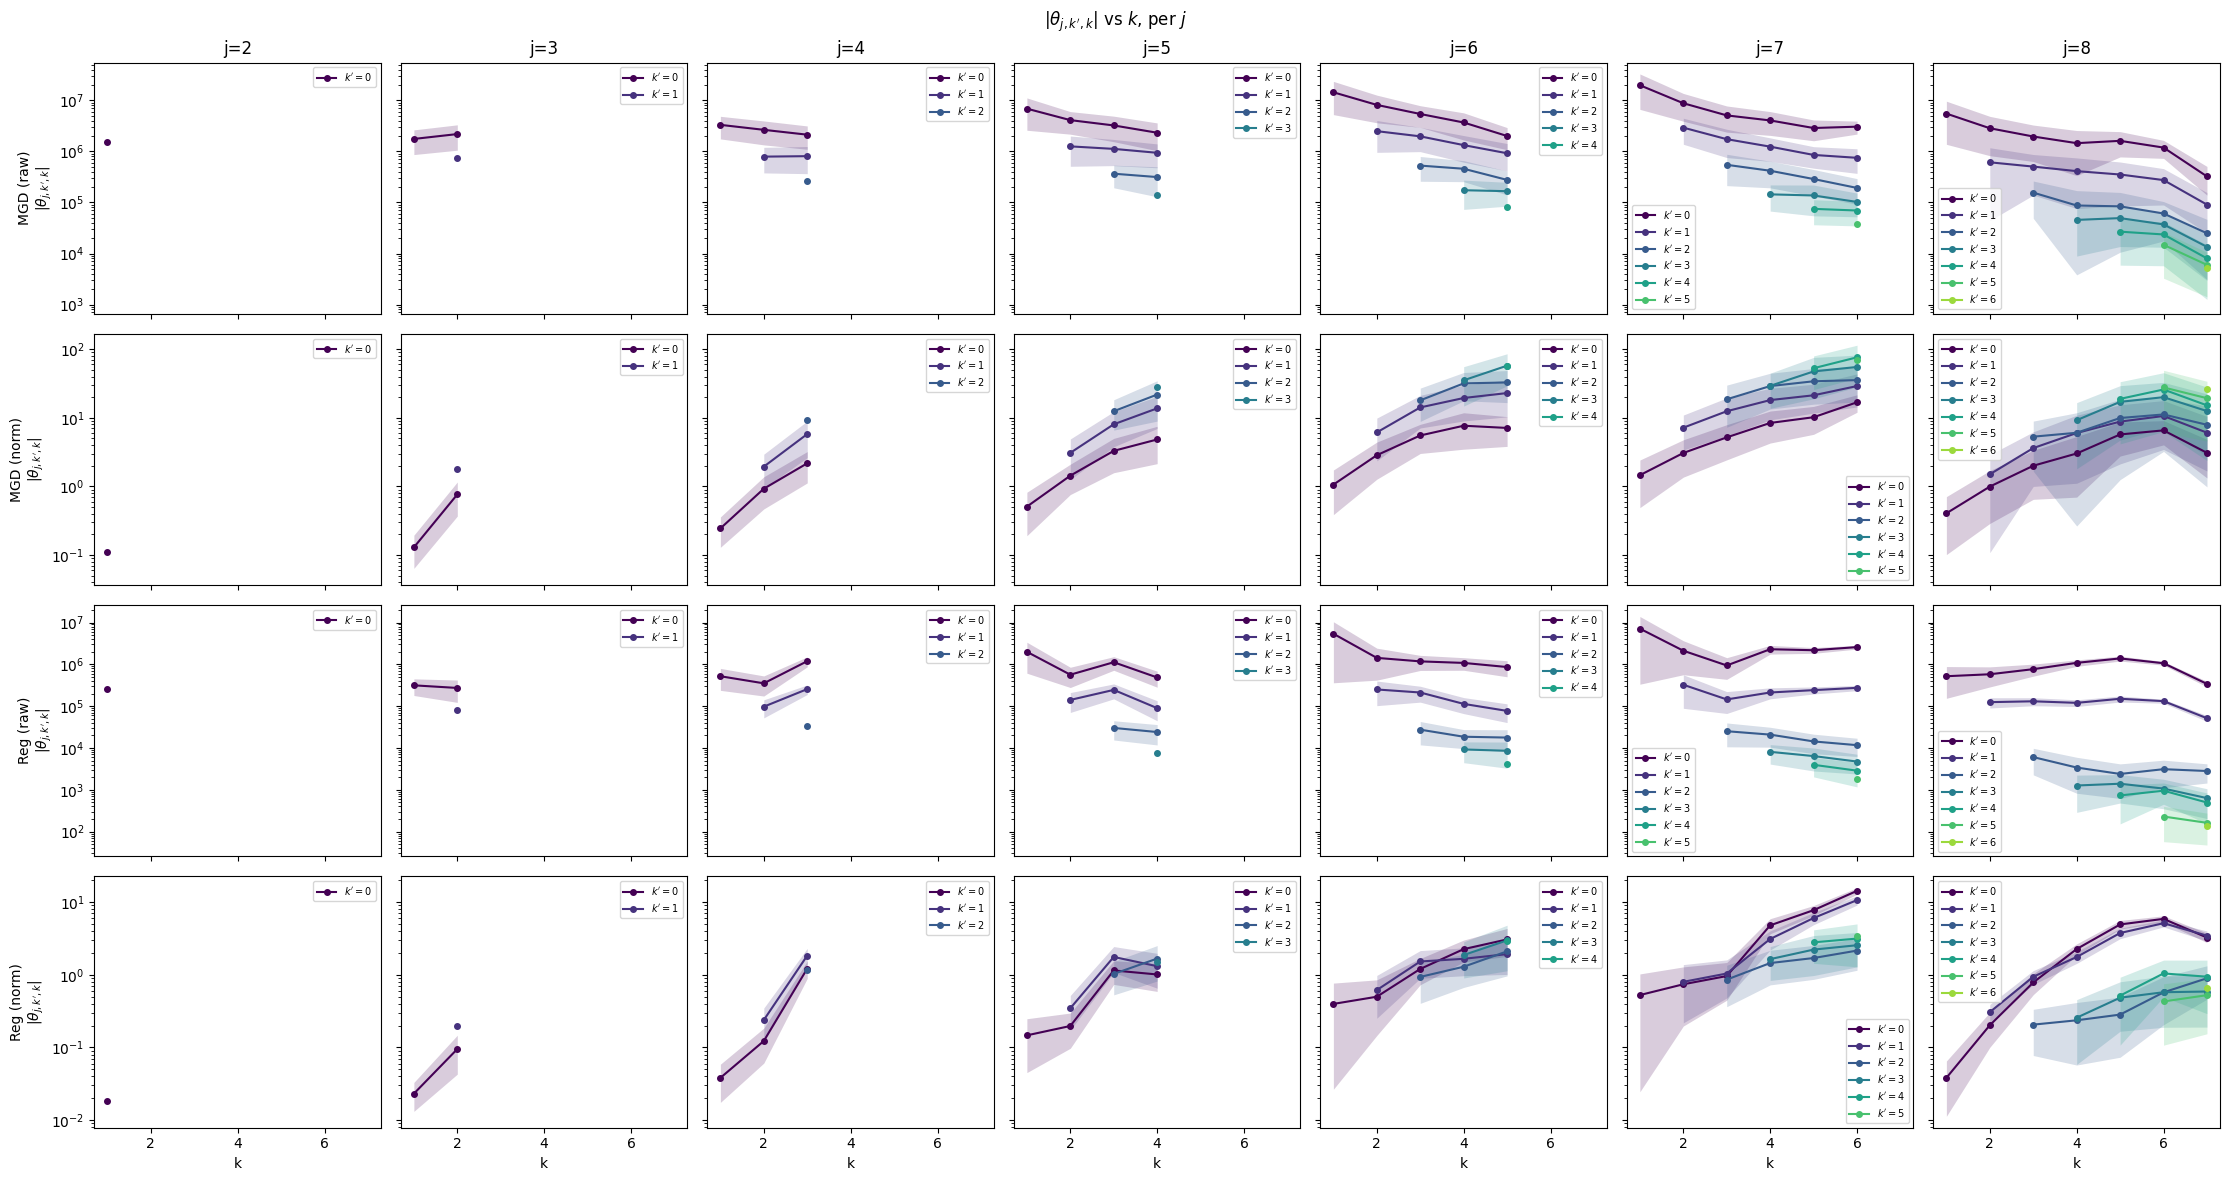

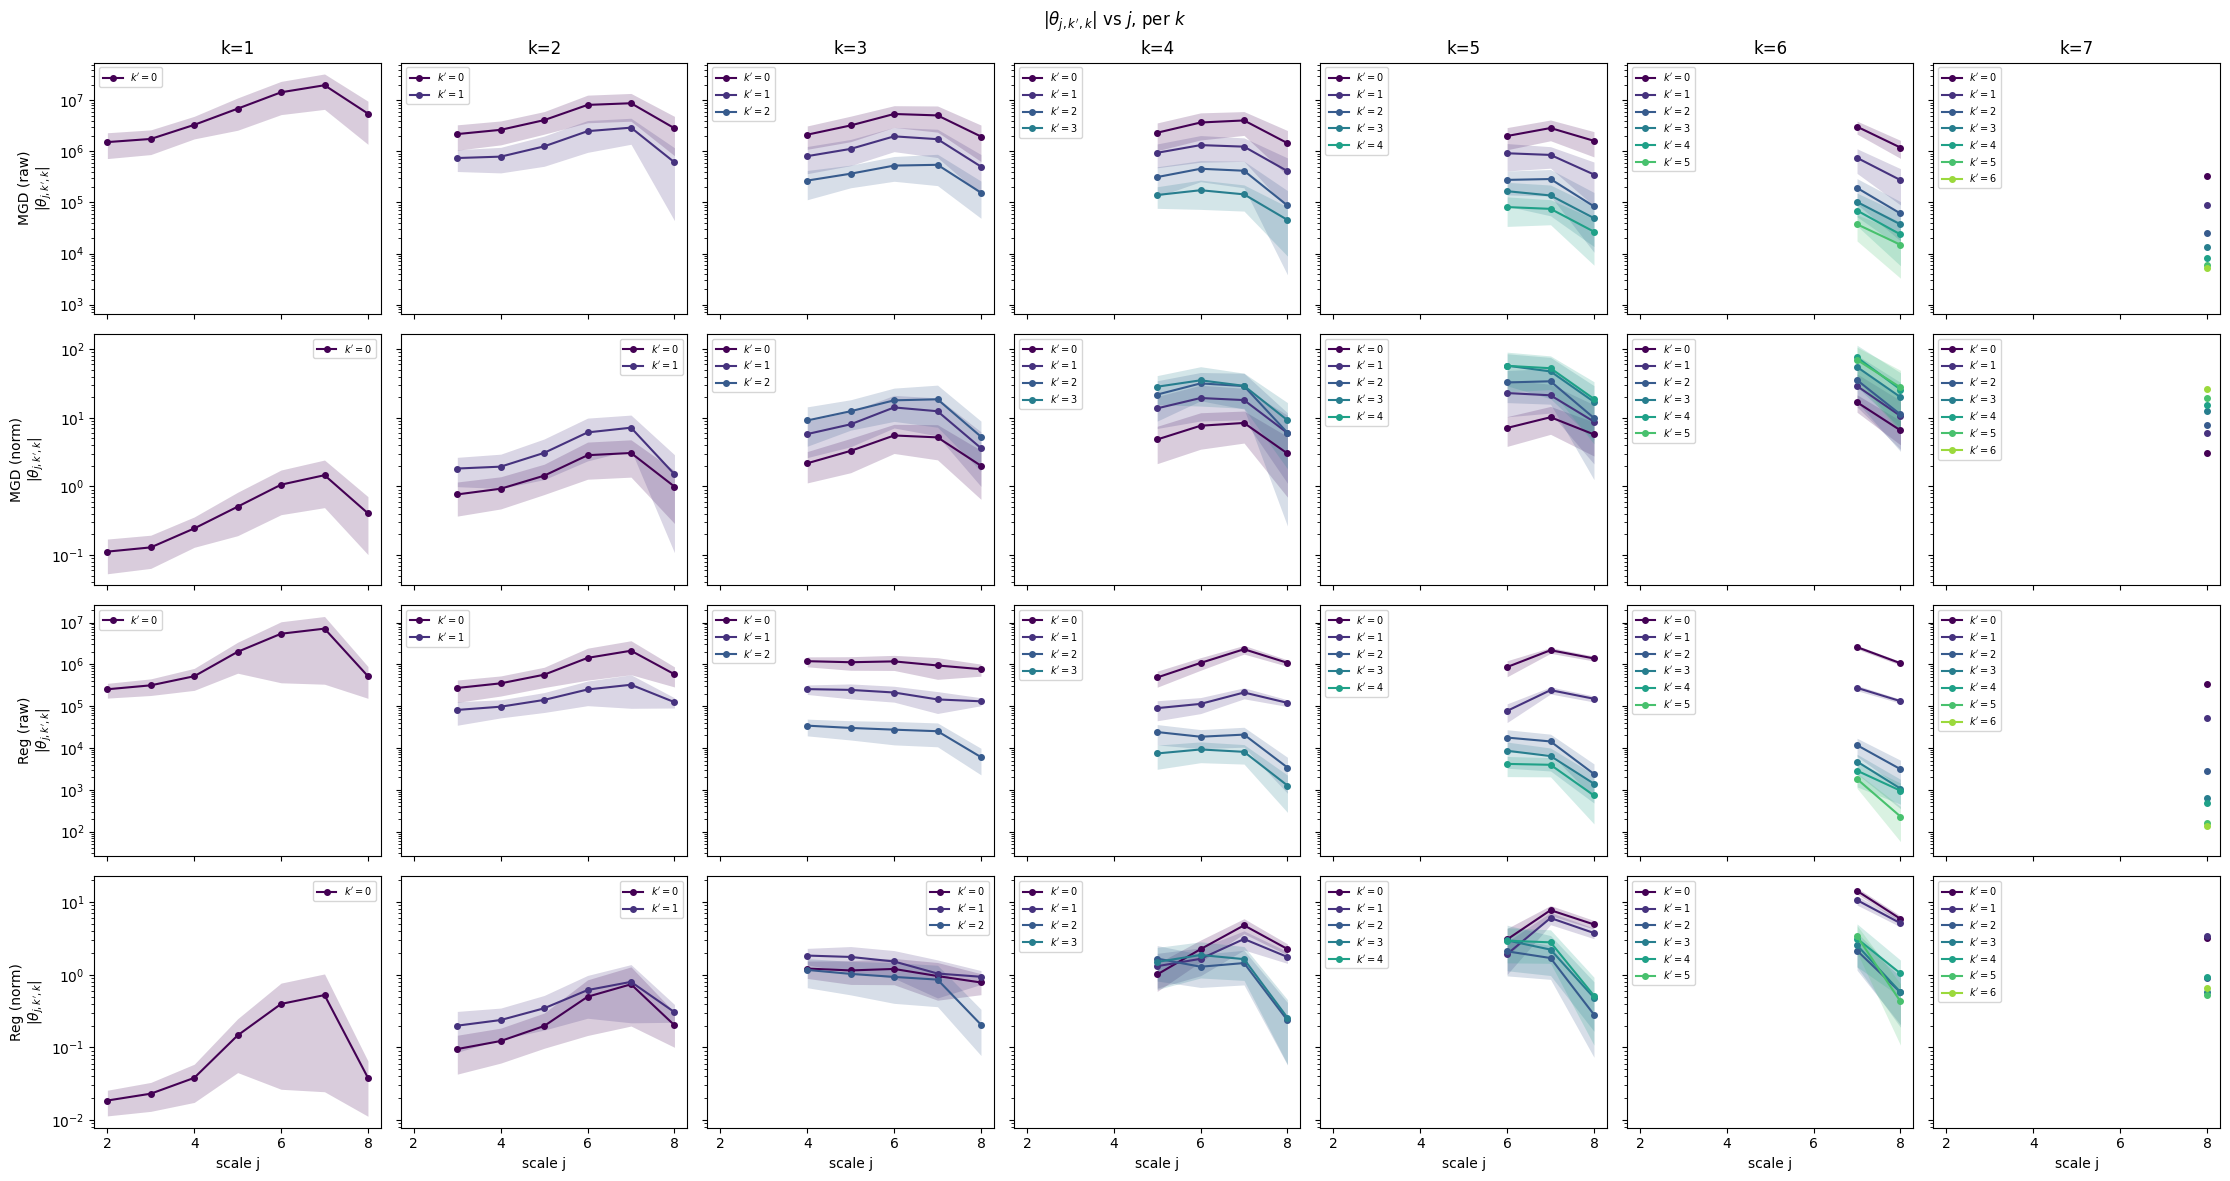

In [72]:
# Replaces the bottom section of the notebook (from
# "Build per-seed dataframes for theta_MGD and theta_reg..." onward).
# Everything above (results loading, reg_all/mgd_all, potential_ranges,
# terms, base_args, root, device, x1, filters) is unchanged. `filters` here
# is the notebook's J+1-channel single-layer filter bank
# (filters = return_Filters(M, J, 1, device=device)) -- it's only used as a
# fallback inside compute_norm_jab if a potential doesn't carry its own
# `.filters` attribute; in practice every potential you've fitted does, so
# pot_re.filters is what actually gets used.

# from theta_analysis_v2 import (
#     compute_mk, build_theta_dataframe, build_complex_theta_dataframe,
#     build_agg_cases, plot_modulus_vs_k_grid, plot_modulus_vs_j_grid,
#     build_all_averaged_vectors, find_matching_reference_potentials,
# )

REAL_KEY = "Scattering_Fourth_Order_Mod2_Real_Q1"
IMAG_KEY = "Scattering_Fourth_Order_Mod2_Imag_Q1"
COMPLEX_NAME = "Scattering_Fourth_Order_Mod2_Q1"

# ------------------------------------------------------------
# 1. Per-seed complex dataframes for the Real+i*Imag scattering coefficient
# ------------------------------------------------------------
dfs = {}              # MGD
dfs_reg = {}           # Reg
potentials_by_seed = {}  # keep each seed's FITTED potentials -- needed below,
                          # since their pruned layout is what actually matches
                          # theta_t on disk, not the nominal get_1d_potentials(...)
mk_by_seed = {}        # matching m_k vector for each seed's fitted potentials
                        # (kept as an optional fallback normalization for
                        # potentials without scattering .indices; the Mod2
                        # pair itself now normalizes via compute_norm_jab)

for key in sorted(results.keys(), key=lambda s: int(s.replace("seed", ""))):
    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)
    potentials_by_seed[key] = potentials_k
    m_k = compute_mk(potentials_k, x1)
    mk_by_seed[key] = m_k

    theta_final = results[key]["theta_t"][-1]
    dfs[key] = build_complex_theta_dataframe(
        theta_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
        # norm_order left as None -> auto-inferred to 4 since 'Mod2' is in REAL_KEY
    )

    theta_reg_final = results[key]["Theta_reg"][-1]
    dfs_reg[key] = build_complex_theta_dataframe(
        theta_reg_final, potentials_k, REAL_KEY, IMAG_KEY, x1=x1, filters=filters,
        combined_name=COMPLEX_NAME, m_k=m_k,
    )

# ------------------------------------------------------------
# 2. |theta_complex| vs k (per j) and vs j (per k), MGD vs Reg, raw + normalized
# ------------------------------------------------------------
cases = {
    'MGD (raw)':  {'dfs': dfs,     'value_col': 'theta_complex'},
    'MGD (norm)': {'dfs': dfs,     'value_col': 'theta_complex_normalized'},
    'Reg (raw)':  {'dfs': dfs_reg, 'value_col': 'theta_complex'},
    'Reg (norm)': {'dfs': dfs_reg, 'value_col': 'theta_complex_normalized'},
}
agg_cases = build_agg_cases(cases)

plot_modulus_vs_k_grid(agg_cases)   # |theta_complex| vs k, one panel per j
plot_modulus_vs_j_grid(agg_cases)   # |theta_complex| vs j, one panel per k

### Compare $\theta_k m_k$ interacting and not-interacting energy components 

Using seed50's fitted potentials for MGD vectors, seed50's for Reg vectors.
L_6                                      shape=(9,)  (real)
L_6_psi                                  shape=(25,)  (real)
L_2_lowpass                              shape=(1,)  (real)
Scalar_psi_gaussianK                     shape=(1,)  (real)
Scalar_morlet_gaussianK                  shape=(27,)  (real)
Scattering_Fourth_Order_Mod2_Q1          shape=(84,)  (complex)
K                4
J                25
num_coefficients 1
Keff             tensor shape=(25,) dtype=torch.int64
active           tensor shape=(25, 4) dtype=torch.bool
active_flat      tensor shape=(1,) dtype=torch.int64
scale            tensor shape=(25, 4) dtype=torch.float32
alpha            tensor shape=(25, 4) dtype=torch.float32
cuts             tensor shape=(25, 3) dtype=torch.float32
pi               tensor shape=(25, 4) dtype=torch.float32
sw               tensor shape=(25, 3) dtype=torch.float32
stat_scale       tensor shape=(1,) dtype=torch.f

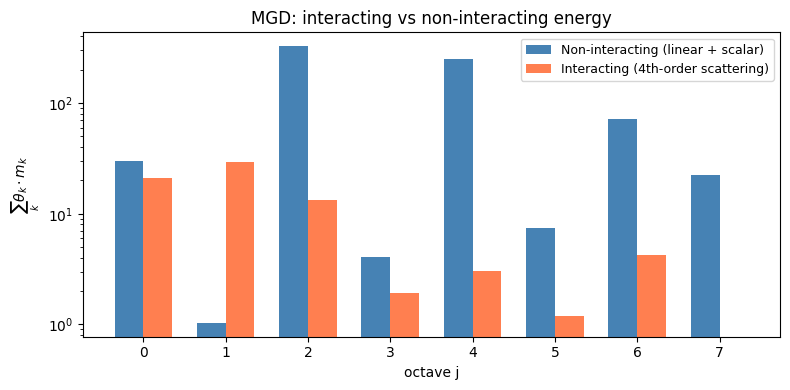

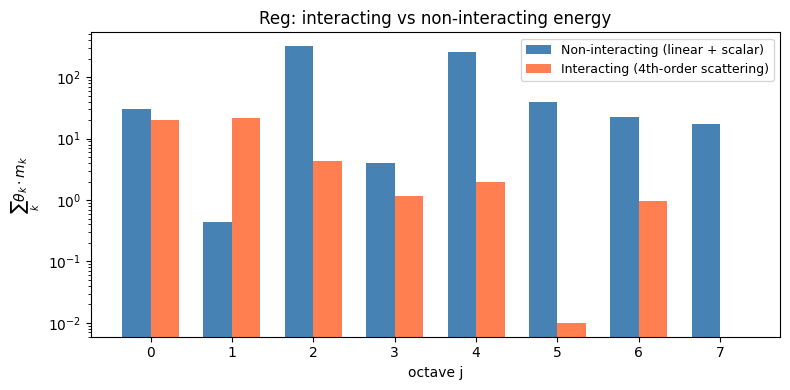

theta_k stdPhi_k, all positive


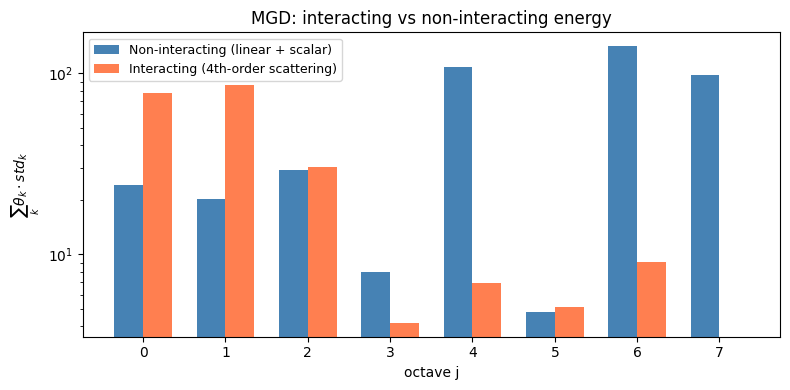

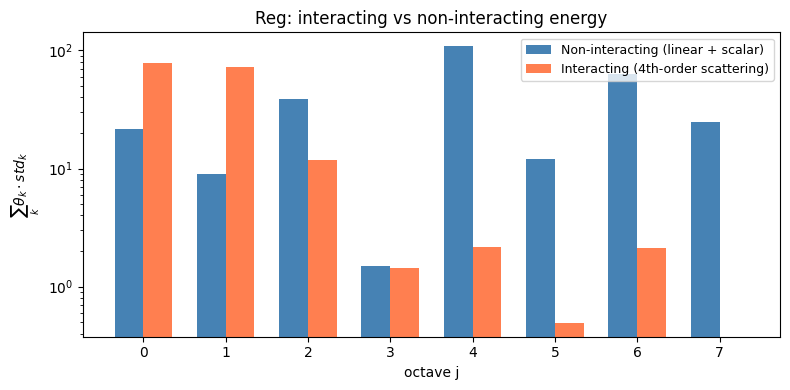

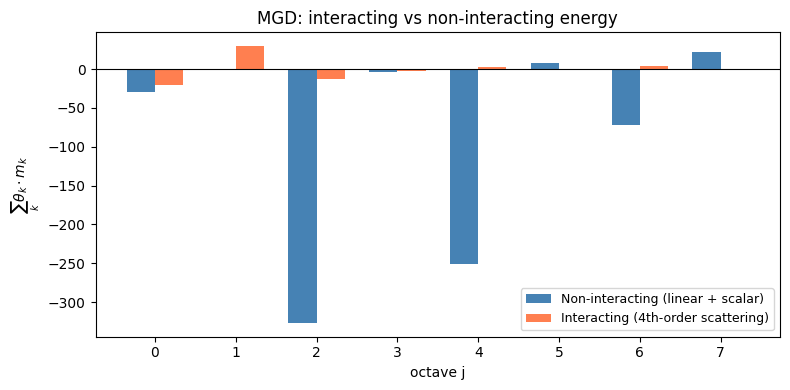

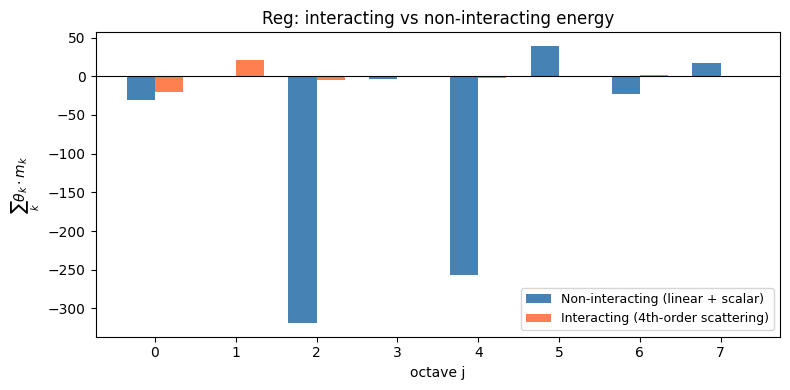

In [66]:

# ------------------------------------------------------------
# 3. Readable, seed-averaged theta vectors for every potential
#    (Real_Q1 + i*Imag_Q1 collapsed into one complex vector; everything
#    else -- L_6, L_6_psi, L_2_lowpass, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK -- stays real)
#
#    Use a reference seed's FITTED potentials (whichever one's pruned
#    layout actually sums to mgd_all's column count) instead of the
#    nominal `potentials` from get_1d_potentials(...) at the top of the
#    notebook -- that nominal one reflects theoretical, un-pruned sizes
#    and will trip the sum(dims) != n_theta assertion.
# ------------------------------------------------------------
real_imag_pairs = [(REAL_KEY, IMAG_KEY, COMPLEX_NAME)]

ref_seed_mgd, ref_potentials_mgd, _ = find_matching_reference_potentials(mgd_all, potentials_by_seed)
ref_seed_reg, ref_potentials_reg, _ = find_matching_reference_potentials(reg_all, potentials_by_seed)
print(f"Using {ref_seed_mgd}'s fitted potentials for MGD vectors, {ref_seed_reg}'s for Reg vectors.")

mgd_vectors = build_all_averaged_vectors(mgd_all, ref_potentials_mgd, terms, real_imag_pairs=real_imag_pairs)
reg_vectors = build_all_averaged_vectors(reg_all, ref_potentials_reg, terms, real_imag_pairs=real_imag_pairs)

# e.g.:
#   mgd_vectors['L_6']                          -> real, shape (9,)
#   mgd_vectors['L_6_psi']                      -> real, shape (25,)
#   mgd_vectors['Scattering_Fourth_Order_Mod2_Q1']  -> complex
#   reg_vectors['Scalar_psi_gaussianK']         -> real

for name, vec in mgd_vectors.items():
    kind = 'complex' if np.iscomplexobj(vec) else 'real'
    print(f"{name:40s} shape={vec.shape}  ({kind})")

# ------------------------------------------------------------
# 4. Matching m_k vectors + octave-level "interacting vs non-interacting"
#    energy comparison: theta_k * m_k, summed within each octave j.
#
#    Non-interacting: L_6, L_6_psi, Scalar_psi_gaussianK,
#    Scalar_morlet_gaussianK (octave-structured) + L_2_lowpass (pure scalar).
#    Interacting: the Real+i*Imag 4th-order scattering potential.
#
#    "psi"-family potentials use Q=3, "morlet"-family use Q=1 -- adjust
#    potential_QJ below if that naming-based guess is wrong for your setup.
# ------------------------------------------------------------
from theta_analysis_v2 import (
    aggregate_octaves_from_QJ, aggregate_by_j, aggregate_potential_to_octaves,
    inspect_fitted_scalar_potential, decode_scalar_channel,
    build_octave_energy_comparison, plot_octave_energy_comparison, decode_mod2_stq,
)

# mk_all must be stacked in the SAME seed order used for mgd_all/reg_all
# (seeds_sorted). If mk_by_seed's key format ("seedN") differs from
# seeds_sorted's (plain ints), adjust the lookup below to match.
mk_all = torch.stack([torch.as_tensor(mk_by_seed[f"seed{s}"]) for s in seeds_sorted])
assert mk_all.shape[0] == mgd_all.shape[0], (
    "mk_all and mgd_all have different seed counts -- their seed sets/order "
    "must match for the vectors below to line up."
)

ref_seed_mk, ref_potentials_mk, _ = find_matching_reference_potentials(mk_all, potentials_by_seed)
mk_vectors = build_all_averaged_vectors(mk_all, ref_potentials_mk, terms, real_imag_pairs=real_imag_pairs)

# --- FIRST: sanity-check the Scalar_* potentials' channel structure on a
# real, fitted object before trusting anything below. Run this once and
# read the output -- Keff/active_flat should be populated (unlike the
# unfitted `potentials` dict), and num_coefficients should equal
# active_flat.sum() / Keff.sum().
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_psi_gaussianK"])
inspect_fitted_scalar_potential(ref_potentials_mgd["Scalar_morlet_gaussianK"])

J = base_args.J
potential_specs = {
    'L_6':     ('QJ', 1),
    'L_6_psi': ('QJ', 3),
    'Scalar_morlet_gaussianK': ('scalar', ref_potentials_mgd["Scalar_morlet_gaussianK"], 1),
    'Scalar_psi_gaussianK':    ('scalar', ref_potentials_mgd["Scalar_psi_gaussianK"], 3),
}
# j2 (coarse, second-layer) index for each scattering coefficient, decoded
# from a real potential whose layout matches theta_vectors[COMPLEX_NAME] --
# i.e. the reference potential used to build mgd_vectors/reg_vectors, not
# the nominal one. Uses decode_mod2_stq (NOT decode_jab): verified against
# Scattering_Fourth_Order_Mod2_Real_1d's actual forward()/fit_micro tensor
# shapes, j2 ranges over [0,J] (J+1 values incl. low-pass) -- decode_jab
# assumed a structurally different, incompatible axis layout for this
# potential family. Ranges over [0,J], so build_octave_energy_comparison
# groups it into J+1 bins internally and reports the low-pass one
# separately (energy_dict['interacting_lowpass']).
j_indices_scatter = decode_mod2_stq(ref_potentials_mgd[REAL_KEY], verbose=False)[0]

energy_mgd = build_octave_energy_comparison(
    mgd_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME, j_indices_interacting=j_indices_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)
energy_reg = build_octave_energy_comparison(
    reg_vectors, mk_vectors, potential_specs,
    interacting_key=COMPLEX_NAME, j_indices_interacting=j_indices_scatter, J=J,
    scalar_potentials=['L_2_lowpass'],
)

print("\nMGD -- non-interacting energy per octave:", energy_mgd['non_interacting_total'])
print("MGD -- interacting energy per octave:    ", energy_mgd['interacting'])
print("MGD -- non-interacting low-pass total:   ", energy_mgd['non_interacting_lowpass_total'])

%matplotlib inline 
print("theta_k m_k, all positive") 
plot_octave_energy_comparison(energy_mgd, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, all_positive = True, title='Reg: interacting vs non-interacting energy')

print("theta_k stdPhi_k, all positive") 
plot_octave_energy_comparison(energy_mgd_std, all_positive = True, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg_std, all_positive = True, title='Reg: interacting vs non-interacting energy')

plot_octave_energy_comparison(energy_mgd, title='MGD: interacting vs non-interacting energy')
plot_octave_energy_comparison(energy_reg, title='Reg: interacting vs non-interacting energy')

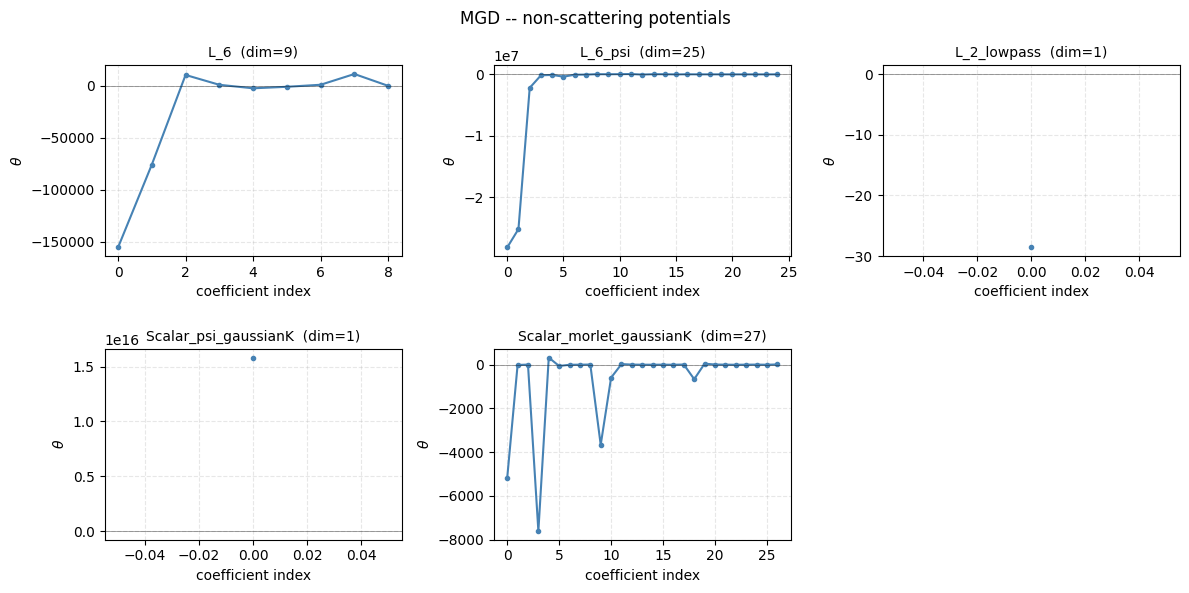

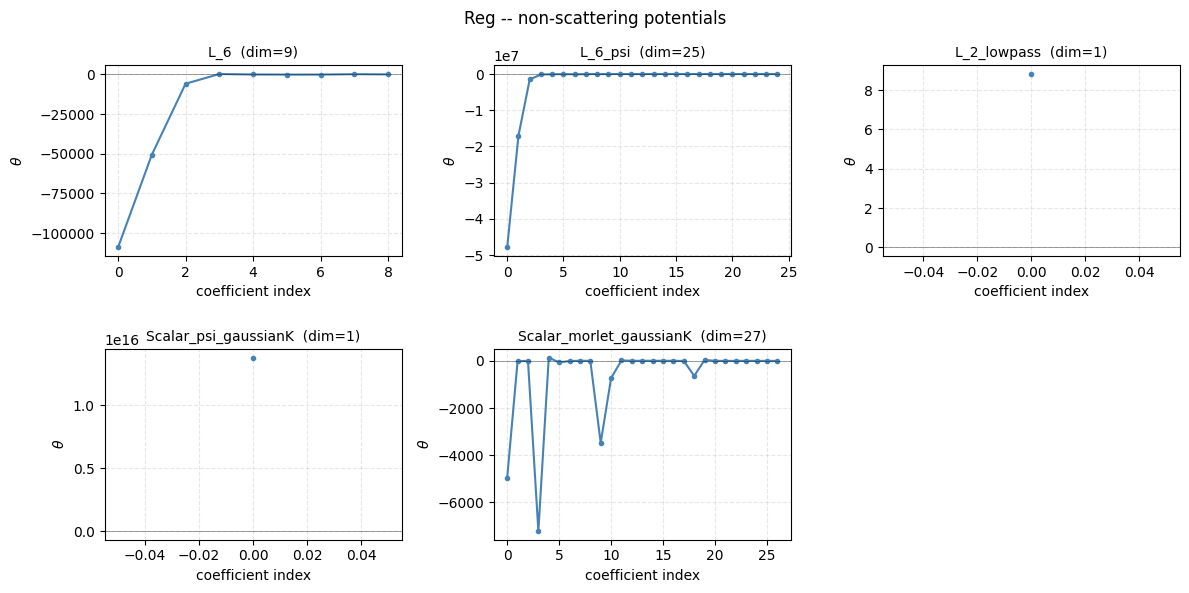

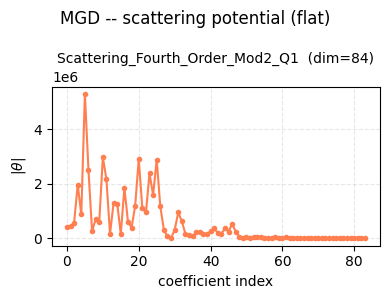

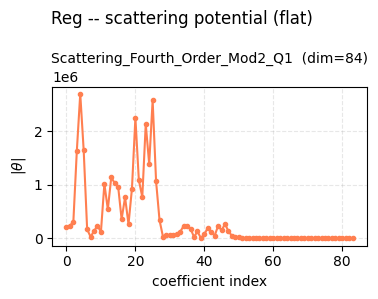

In [74]:
non_scattering_names = [k for k in mgd_vectors.keys() if k != COMPLEX_NAME]

plot_theta_by_potential(mgd_vectors, potential_names=non_scattering_names,
                         title='MGD -- non-scattering potentials')
plot_theta_by_potential(reg_vectors, potential_names=non_scattering_names,
                         title='Reg -- non-scattering potentials')

plot_theta_by_potential(mgd_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='MGD -- scattering potential (flat)')
plot_theta_by_potential(reg_vectors, potential_names=[COMPLEX_NAME], ncols=1,
                         title='Reg -- scattering potential (flat)')

In [54]:
energy_reg

{'non_interacting_by_potential': {'L_6': (array([-0.0858538 , -0.35984406, -0.27190915,  0.02672716, -0.01741422,
          -0.08278739, -0.16810133,  0.78927046], dtype=float32),
   1.0593318939208984),
  'L_6_psi': (array([-0.0657623 , -0.07472201, -0.1561963 , -0.02895124, -0.01667676,
           0.1210533 , -0.17389503, -0.44737825], dtype=float32),
   -0.5579615831375122),
  'Scalar_morlet_gaussianK': (array([ -73.35576  ,    0.       , -318.17447  ,   -4.0001187,
          -257.26923  ,   38.811337 ,  -22.100594 ,   17.11129  ],
         dtype=float32),
   13.082194328308105),
  'Scalar_psi_gaussianK': (array([43.454414,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
           0.      ,  0.      ], dtype=float32),
   0.0),
  'L_2_lowpass': (array([0., 0., 0., 0., 0., 0., 0., 0.]), 5.594386100769043)},
 'non_interacting_total': array([ -30.0529604 ,   -0.43456607, -318.60257444,   -4.00234281,
        -257.30331706,   38.84960243,  -22.44258992,   17.45318219]),
 'non_int